In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import tensorflow as tf
from sklearn.base import BaseEstimator, RegressorMixin
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
 
import warnings
 
warnings.filterwarnings(
    "ignore",
    message="Do not pass an `input_shape`/`input_dim` argument to a layer.*",
    category=UserWarning
)

In [2]:
energy_dataset = pd.read_csv("energy_dataset.csv")
energy_dataset

,time,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_coal-derived_gas,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_fossil_oil_shale,generation_fossil_peat,generation_geothermal,...,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_offshore,generation_wind_onshore,forecast_wind_offshore_eday_ahead,total_load_actual,price_day_ahead
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,NaN,25385.0,50.10
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,NaN,24382.0,48.10
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,NaN,22734.0,47.33
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,NaN,21286.0,42.27
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,NaN,20264.0,38.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,297.0,0.0,0.0,7634.0,2628.0,178.0,0.0,0.0,0.0,...,6073.0,63.0,95.0,85.0,277.0,0.0,3113.0,NaN,30653.0,68.85
35060,2018-12-31 20:00:00+01:00,296.0,0.0,0.0,7241.0,2566.0,174.0,0.0,0.0,0.0,...,6074.0,62.0,95.0,33.0,280.0,0.0,3288.0,NaN,29735.0,68.40
35061,2018-12-31 21:00:00+01:00,292.0,0.0,0.0,7025.0,2422.0,168.0,0.0,0.0,0.0,...,6076.0,61.0,94.0,31.0,286.0,0.0,3503.0,NaN,28071.0,66.88
35062,2018-12-31 22:00:00+01:00,293.0,0.0,0.0,6562.0,2293.0,163.0,0.0,0.0,0.0,...,6075.0,61.0,93.0,31.0,287.0,0.0,3586.0,NaN,25801.0,63.93


# Data preparation and pre-processing

In [3]:
print("Number of predictors:", energy_dataset.shape[1])

missing_values_df = energy_dataset.isnull().sum()
print(missing_values_df)

print("Dataset statistics")
energy_dataset.describe().T

Number of predictors: 25
time                                               0
generation_biomass                                19
generation_fossil_brown_coal_lignite              18
generation_fossil_coal-derived_gas                18
generation_fossil_gas                             18
generation_fossil_hard_coal                       18
generation_fossil_oil                             19
generation_fossil_oil_shale                       18
generation_fossil_peat                            18
generation_geothermal                             18
generation_hydro_pumped_storage_aggregated     35064
generation_hydro_pumped_storage_consumption       19
generation_hydro_run-of-river_and_poundage        19
generation_hydro_water_reservoir                  18
generation_marine                                 19
generation_nuclear                                17
generation_other                                  18
generation_other_renewable                        18
generation_solar     

,count,mean,std,min,25%,50%,75%,max
generation_biomass,35045.0,383.513540,85.353943,0.00,333.00,367.00,433.00,592.00
generation_fossil_brown_coal_lignite,35046.0,448.059208,354.568590,0.00,0.00,509.00,757.00,999.00
generation_fossil_coal-derived_gas,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_fossil_gas,35046.0,5622.737488,2201.830478,0.00,4126.00,4969.00,6429.00,20034.00
generation_fossil_hard_coal,35046.0,4256.065742,1961.601013,0.00,2527.00,4474.00,5838.75,8359.00
generation_fossil_oil,35045.0,298.319789,52.520673,0.00,263.00,300.00,330.00,449.00
generation_fossil_oil_shale,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_fossil_peat,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_geothermal,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_hydro_pumped_storage_aggregated,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- There are columns where all values are missing: forecast_wind_offshore_eday_ahead, generation_hydro_pumped_storage_aggregated;
- By the descriptive statistics it is also possible to ensure that the variables generation_fossil_coal-derived_gas, generation_fossil_oil_shale, generation_fossil_peat, generation_geothermal, generation_marine and generation_wind_offshore have all the values as 0.

For that reason the following columns will be removed:
[forecast_wind_offshore_eday_ahead, generation_hydro_pumped_storage_aggregated, generation_fossil_coal-derived_gas, generation_fossil_oil_shale, generation_fossil_peat, generation_geothermal, generation_marine, generation_wind_offshore].

In [4]:
features_to_remove = ['forecast_wind_offshore_eday_ahead', 'generation_hydro_pumped_storage_aggregated', 'generation_fossil_coal-derived_gas', 
                      'generation_fossil_oil_shale', 'generation_fossil_peat', 'generation_geothermal', 'generation_marine', 'generation_wind_offshore']
print(energy_dataset.columns)
energy_dataset = energy_dataset.drop(features_to_remove, axis = 1)
print(energy_dataset.columns)
energy_dataset

Index(['time', 'generation_biomass', 'generation_fossil_brown_coal_lignite',
       'generation_fossil_coal-derived_gas', 'generation_fossil_gas',
       'generation_fossil_hard_coal', 'generation_fossil_oil',
       'generation_fossil_oil_shale', 'generation_fossil_peat',
       'generation_geothermal', 'generation_hydro_pumped_storage_aggregated',
       'generation_hydro_pumped_storage_consumption',
       'generation_hydro_run-of-river_and_poundage',
       'generation_hydro_water_reservoir', 'generation_marine',
       'generation_nuclear', 'generation_other', 'generation_other_renewable',
       'generation_solar', 'generation_waste', 'generation_wind_offshore',
       'generation_wind_onshore', 'forecast_wind_offshore_eday_ahead',
       'total_load_actual', 'price_day_ahead'],
      dtype='object')
Index(['time', 'generation_biomass', 'generation_fossil_brown_coal_lignite',
       'generation_fossil_gas', 'generation_fossil_hard_coal',
       'generation_fossil_oil', 'generatio

,time,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_onshore,total_load_actual,price_day_ahead
0,2015-01-01 00:00:00+01:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10
1,2015-01-01 01:00:00+01:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10
2,2015-01-01 02:00:00+01:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33
3,2015-01-01 03:00:00+01:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27
4,2015-01-01 04:00:00+01:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,297.0,0.0,7634.0,2628.0,178.0,1.0,1135.0,4836.0,6073.0,63.0,95.0,85.0,277.0,3113.0,30653.0,68.85
35060,2018-12-31 20:00:00+01:00,296.0,0.0,7241.0,2566.0,174.0,1.0,1172.0,3931.0,6074.0,62.0,95.0,33.0,280.0,3288.0,29735.0,68.40
35061,2018-12-31 21:00:00+01:00,292.0,0.0,7025.0,2422.0,168.0,50.0,1148.0,2831.0,6076.0,61.0,94.0,31.0,286.0,3503.0,28071.0,66.88
35062,2018-12-31 22:00:00+01:00,293.0,0.0,6562.0,2293.0,163.0,108.0,1128.0,2068.0,6075.0,61.0,93.0,31.0,287.0,3586.0,25801.0,63.93


In [7]:
weather_dataset = pd.read_csv("weather.csv")
weather_dataset

,time,temperature,pressure,humidity,wind_speed
0,2015-01-01 00:00:00+01:00,272.491463,1021.3,82.4,2.0
1,2015-01-01 01:00:00+01:00,272.512700,1021.2,82.4,2.0
2,2015-01-01 02:00:00+01:00,272.151937,1021.6,82.0,2.4
3,2015-01-01 03:00:00+01:00,272.142269,1021.5,82.0,2.4
4,2015-01-01 04:00:00+01:00,272.198700,1021.5,82.0,2.4
...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,284.470000,1029.2,73.6,1.4
35060,2018-12-31 20:00:00+01:00,282.294000,1030.0,68.0,1.8
35061,2018-12-31 21:00:00+01:00,280.850000,1029.8,71.4,2.6
35062,2018-12-31 22:00:00+01:00,279.718000,1030.2,70.0,2.8


In [8]:
print("Number of predictors:", weather_dataset.shape[1])

missing_values_df = weather_dataset.isnull().sum()
print(missing_values_df)

print("Dataset statistics")
weather_dataset.describe().T

Number of predictors: 5
time           0
temperature    0
pressure       0
humidity       0
wind_speed     0
dtype: int64
Dataset statistics


,count,mean,std,min,25%,50%,75%,max
temperature,35064.0,289.706862,7.251796,272.006,284.098877,289.0362,295.1005,309.048
pressure,35064.0,1017.297872,6.363845,999.500,1013.475000,1017.0000,1021.0000,1035.500
humidity,35064.0,68.033025,14.814871,22.600,56.750000,69.6000,80.0000,100.000
wind_speed,35064.0,2.442944,1.276415,0.000,1.400000,2.2000,3.2000,8.500


In [9]:
df = pd.merge(energy_dataset, weather_dataset, on="time", how="inner")
df['time'] = pd.to_datetime(df['time'], utc = True)
df.set_index('time', inplace=True)
df = df.asfreq('h')
df

,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_onshore,total_load_actual,price_day_ahead,temperature,pressure,humidity,wind_speed
time,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10,272.491463,1021.3,82.4,2.0
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10,272.512700,1021.2,82.4,2.0
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33,272.151937,1021.6,82.0,2.4
2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27,272.142269,1021.5,82.0,2.4
2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41,272.198700,1021.5,82.0,2.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 18:00:00+00:00,297.0,0.0,7634.0,2628.0,178.0,1.0,1135.0,4836.0,6073.0,63.0,95.0,85.0,277.0,3113.0,30653.0,68.85,284.470000,1029.2,73.6,1.4
2018-12-31 19:00:00+00:00,296.0,0.0,7241.0,2566.0,174.0,1.0,1172.0,3931.0,6074.0,62.0,95.0,33.0,280.0,3288.0,29735.0,68.40,282.294000,1030.0,68.0,1.8
2018-12-31 20:00:00+00:00,292.0,0.0,7025.0,2422.0,168.0,50.0,1148.0,2831.0,6076.0,61.0,94.0,31.0,286.0,3503.0,28071.0,66.88,280.850000,1029.8,71.4,2.6


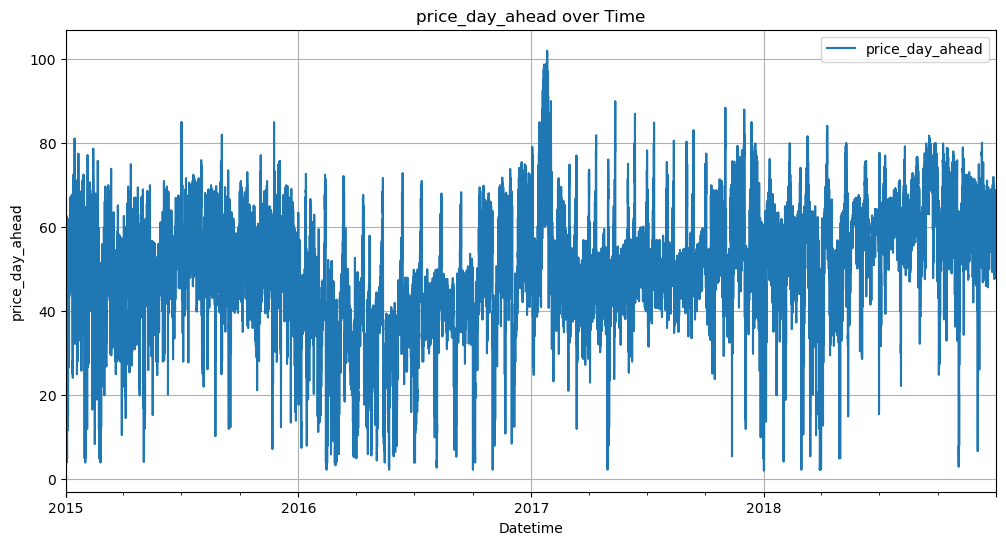

In [9]:
df.plot(y='price_day_ahead', figsize=(12, 6), title='price_day_ahead over Time')
plt.xlabel('Datetime')
plt.ylabel('price_day_ahead')
plt.grid(True)
plt.show()

From the time series graphic we can see the evolution of price_day_ahead over time. Is it possible to verify seasonal patterns over the years but we will plot the rolling mean and standard derivation using different window lengths in order to highlight recurring patterns.

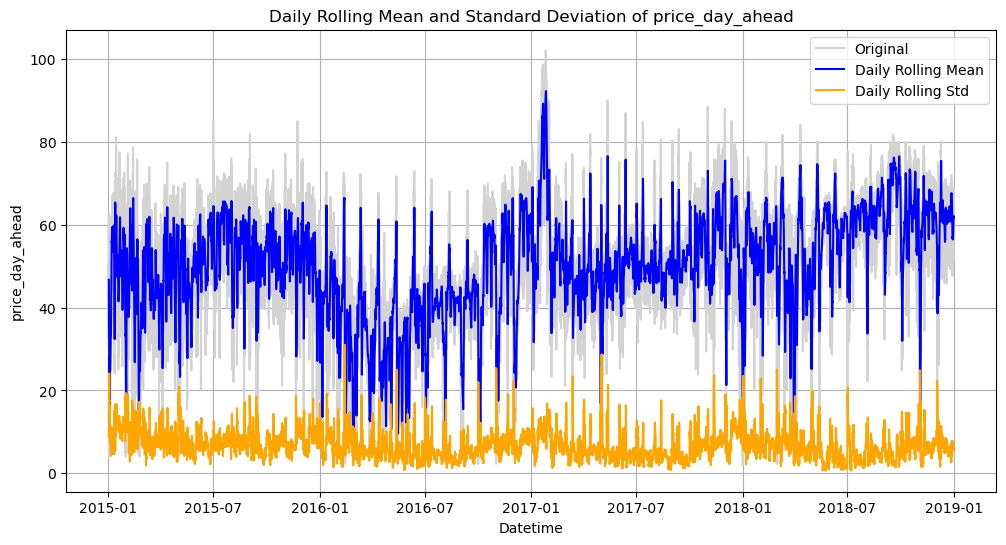

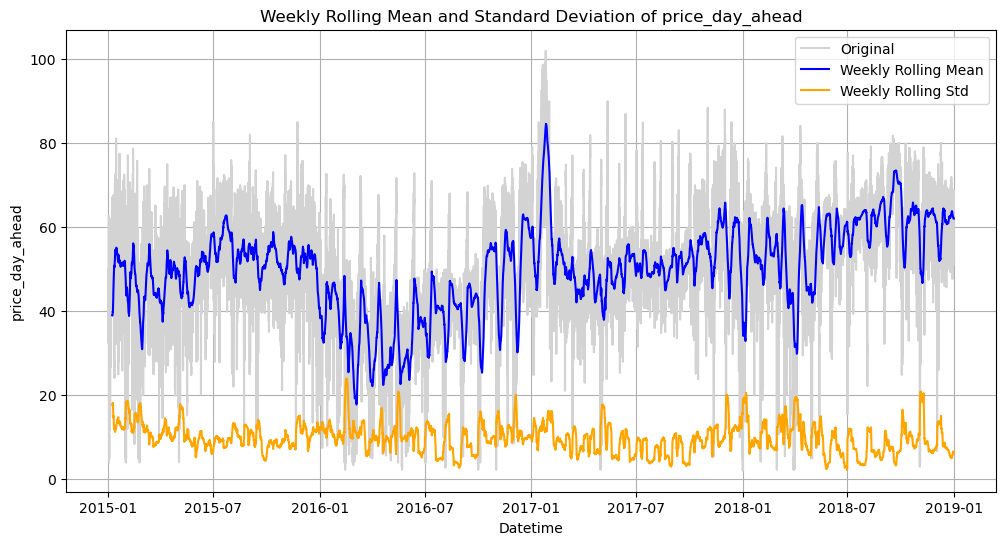

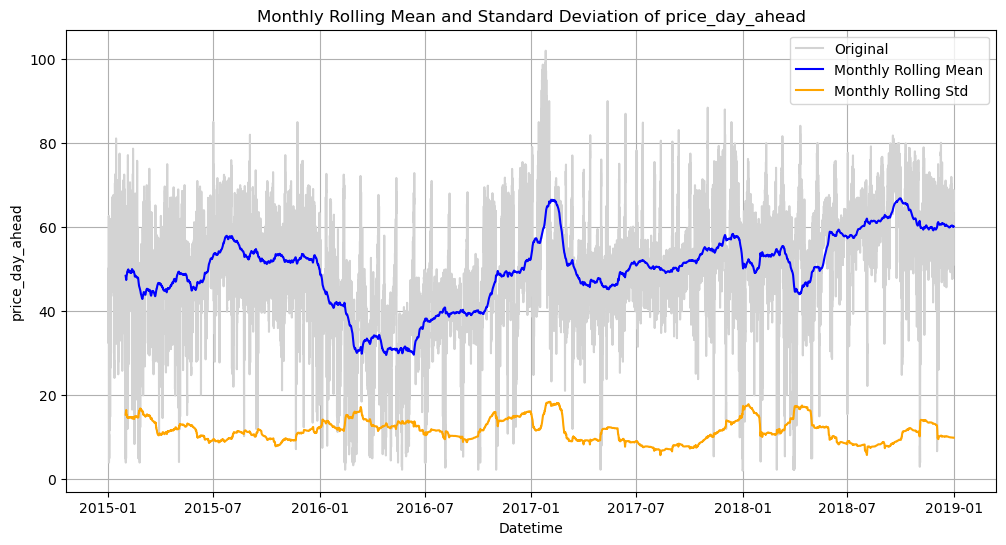

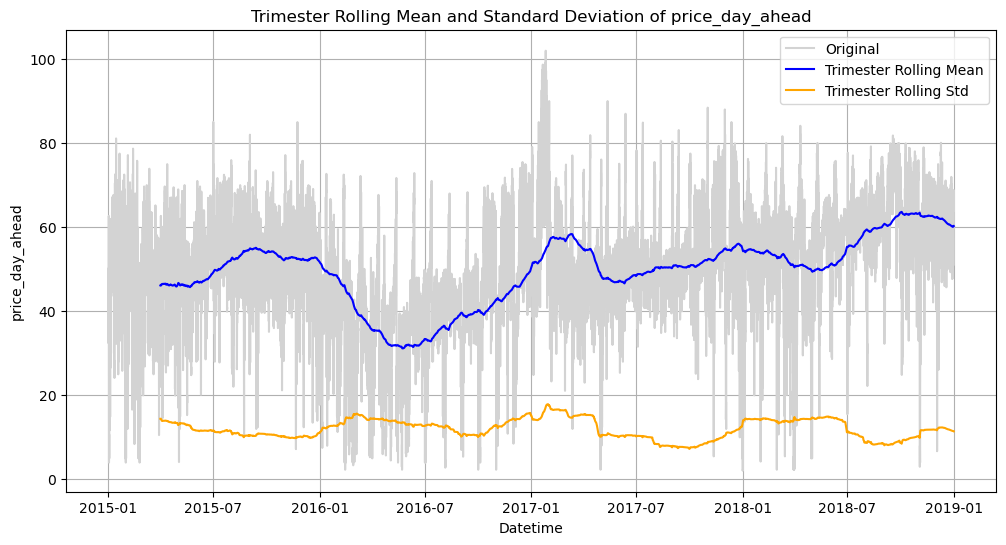

In [10]:
time_windows = {
    24: 'Daily',
    168: 'Weekly',    
    720: 'Monthly',    
    2160: 'Trimester'
}

for time_win, freq in time_windows.items():
    rolling_mean = df['price_day_ahead'].rolling(window=time_win).mean()
    rolling_std = df['price_day_ahead'].rolling(window=time_win).std()
    
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['price_day_ahead'], color='lightgray', label='Original')
    plt.plot(df.index, rolling_mean, color='blue', label=f'{freq} Rolling Mean')
    plt.plot(df.index, rolling_std, color='orange', label=f'{freq} Rolling Std')
    
    plt.title(f'{freq} Rolling Mean and Standard Deviation of price_day_ahead')
    plt.xlabel('Datetime')
    plt.ylabel('price_day_ahead')
    plt.legend()
    plt.grid(True)
    plt.show()

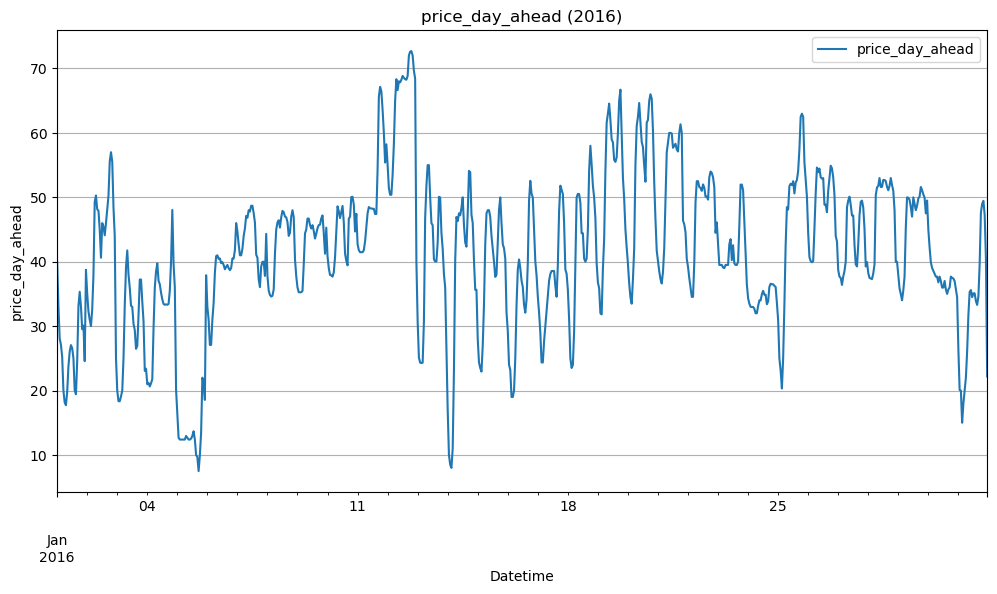

In [11]:
df.loc['2016-01'].plot(
    y='price_day_ahead',
    figsize=(12, 6),
    title='price_day_ahead (2016)'
)

plt.xlabel('Datetime')
plt.ylabel('price_day_ahead')
plt.grid(True)
plt.show()

##### Missing Values

In a time series, missing values can represent gaps or interruptions, which may distort analysis and forecasting if not properly handled. To address this, we will use nearest interpolation.

Nearest Interpolation works by filling missing values with the closest observed value, combining the effects of both forward and backward filling. This approach helps to:
- Maintain the consistency of trends and tendencies in the data
- Avoid introducing artificial jumps or smoothing that could distort short-term dynamics

In [10]:
print('Dataset missing values')
missing_values_df = df.isnull().sum()
print(missing_values_df)

df = df.interpolate(method='nearest')

print()
print('Dataset after missing values being filled using Nearest Interpolation')
print(df.isnull().sum())

Dataset missing values
generation_biomass                             19
generation_fossil_brown_coal_lignite           18
generation_fossil_gas                          18
generation_fossil_hard_coal                    18
generation_fossil_oil                          19
generation_hydro_pumped_storage_consumption    19
generation_hydro_run-of-river_and_poundage     19
generation_hydro_water_reservoir               18
generation_nuclear                             17
generation_other                               18
generation_other_renewable                     18
generation_solar                               18
generation_waste                               19
generation_wind_onshore                        18
total_load_actual                              36
price_day_ahead                                 0
temperature                                     0
pressure                                        0
humidity                                        0
wind_speed                 

##### Data Split
The final 12 months will be used as test set. The remaining data will be used as training set.

In [11]:
# Number of months to use as test set
test_size = 365 * 24 - 1

train = df.iloc[:-test_size]  # all rows except last 24 months
test = df.iloc[-test_size:]   # last 24 months

print(f"Training set shape: {train.shape}")
print(f"Test set shape: {test.shape}")
print(f"Training period: {train.index.min()} to {train.index.max()}")
print(f"Test period: {test.index.min()} to {test.index.max()}")

X_train = train.drop(columns=['price_day_ahead'])
y_train = train['price_day_ahead']

X_test = test.drop(columns=['price_day_ahead'])
y_test = test['price_day_ahead']

Training set shape: (26305, 20)
Test set shape: (8759, 20)
Training period: 2014-12-31 23:00:00+00:00 to 2017-12-31 23:00:00+00:00
Test period: 2018-01-01 00:00:00+00:00 to 2018-12-31 22:00:00+00:00


# Modeling

For evaluation purposes, all optimized models will be stored in a map to be evaluated latter.

In [14]:
models = {}

### Statistical models

##### Stationary Testing and ACF/PACF analysis

In [15]:
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(df['price_day_ahead'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -12.288647154284345
p-value: 7.919257782286934e-23


Stationary time series. p-value < 0.05, H0 rejected.

Differencing is not required.

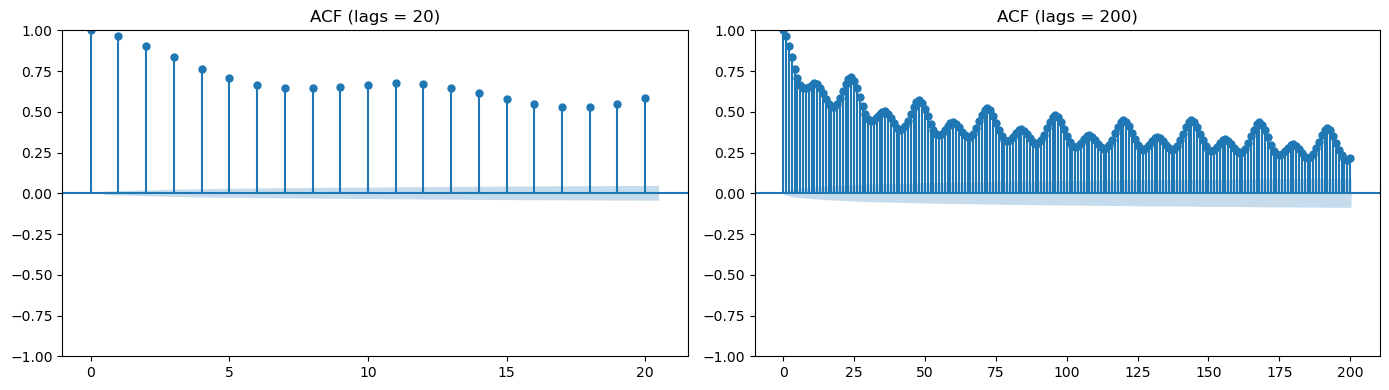

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

series = df['price_day_ahead']


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Short-term ACF (non-seasonal structure)
plot_acf(series, lags=20, ax=axes[0])
axes[0].set_title("ACF (lags = 20)")

# Long-term ACF (seasonality detection)
plot_acf(series, lags=200, ax=axes[1])
axes[1].set_title("ACF (lags = 200)")

plt.tight_layout()
plt.show()

##### ACF interpretation
- The autocorrelation function exhibits a slow decay across lags, with correlations remaining significantly positive for many lags.
- All lags are significantly positive.
- When we expand the number of lags, is it possible to observe a wave repeating pattern, which can suggest the existence of seasonality in the time series. 

##### Conclusions
From the ACF plot, we can conclud that this time series does not represent a MA(q) process. On a MA(q) series coeficients would become abruptly non-significant in ACF, indicating the order of the Moving Average series. 

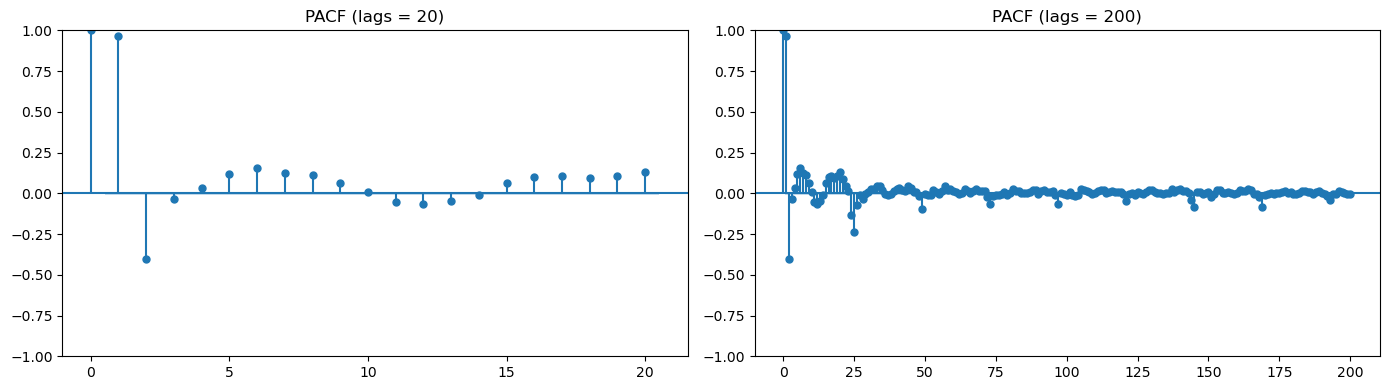

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Short-term ACF (non-seasonal structure)
plot_pacf(series, lags=20, ax=axes[0])
axes[0].set_title("PACF (lags = 20)")

# Long-term ACF (seasonality detection)
plot_pacf(series, lags=200, ax=axes[1])
axes[1].set_title("PACF (lags = 200)")

plt.tight_layout()
plt.show()

##### PACF interpretation
- The PACF shows coeficients becoming abruptly non-significant at lag 2, indicating an autoregressive structure of order 2.
- When extending the PACF to a larger number of lags, a significant spike at lag 24 is observed, revealing the presence of daily seasonality in the hourly time series.
-Beyond the seasonal lag, partial autocorrelations remain close to zero, suggesting that higher-order autoregressive terms are unnecessary.

##### Conclusions
The PACF analysis indicates that the series follows an AR(2) process.

##### Seasonal P and Q analysis
- The presence of a single significant spike at the seasonal lag (24) in the PACF indicates a seasonal autoregressive component of order 1 (P = 1).
- No abrupt cutoff is observed in the ACF at the seasonal lag or its multiples, which suggests the absence of a seasonal moving-average component (Q = 0).
- The seasonal dependence therefore appears to be captured by a seasonal AR term rather than a seasonal MA term.

D and d analysis

In [19]:
# # Commented due to long running time | Total fit time: 870.239s

# import pmdarima as pm
# from statsmodels.tsa.statespace.kalman_filter import MEMORY_CONSERVE

# auto_sarima = pm.auto_arima(
#     y_train.loc['2017'],
#     start_p=0, max_p=2,
#     start_q=0, max_q=0,
#     start_P=0, max_P=3,
#     start_Q=0, max_Q=1,
#     d=0, D=0,
#     seasonal=True,
#     m=24,
#     stepwise=False,
#     n_jobs=-1,
#     trace=True,
#     error_action='ignore',
#     suppress_warnings=True,
#     sarimax_kwargs={'conserve_memory': MEMORY_CONSERVE}
# )


# # best (2,0,0)(3,0,0)[24]

best: (2,0,0)(3,0,0)[24]

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# from auto_arima results (2,0,0)(3,0,0)[24]

order=(2,0,0)
seasonal_order=(3,0,0,24)

# SARIMA Model
sarima_model = SARIMAX(
    y_train.loc['2017'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# 1-step ahead forecast (next hour)
sarima_forecast_1h = sarima_model.get_forecast(steps=1).predicted_mean

# 24-step ahead forecast (next day)
sarima_forecast_24h = sarima_model.get_forecast(steps=24).predicted_mean

# Store SARIMA model
models['SARIMA'] = sarima_model

In [23]:
# SARIMAX Model (with exogenous variables)

sarimax_model = SARIMAX(
    y_train.loc['2017'],
    order=order,
    seasonal_order=seasonal_order,
    exog=X_train.loc['2017'],
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecasts with exogenous variables
sarimax_forecast_1h = sarimax_model.get_forecast(
    steps=1, exog=X_test.iloc[:1]
).predicted_mean
sarimax_forecast_1h.index = y_test.iloc[:1].index  # Align index

sarimax_forecast_24h = sarimax_model.get_forecast(
    steps=24, exog=X_test.iloc[:24]
).predicted_mean
sarimax_forecast_24h.index = y_test.iloc[:24].index  # Align index

# Store SARIMAX model
models['SARIMAX'] = sarimax_model

C:\Users\jorge\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


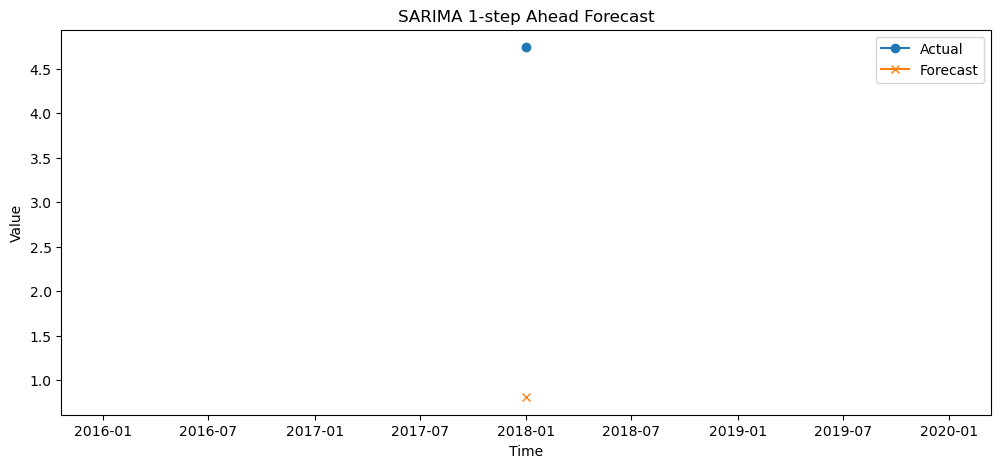

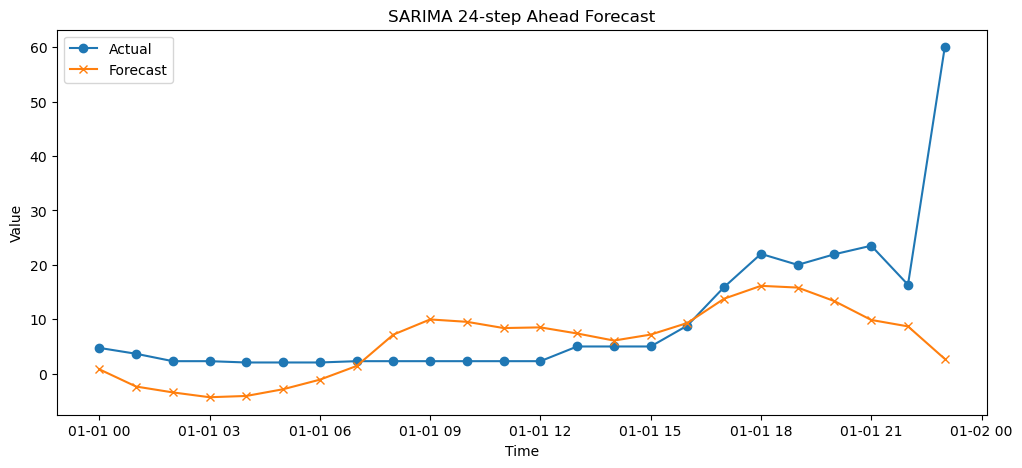

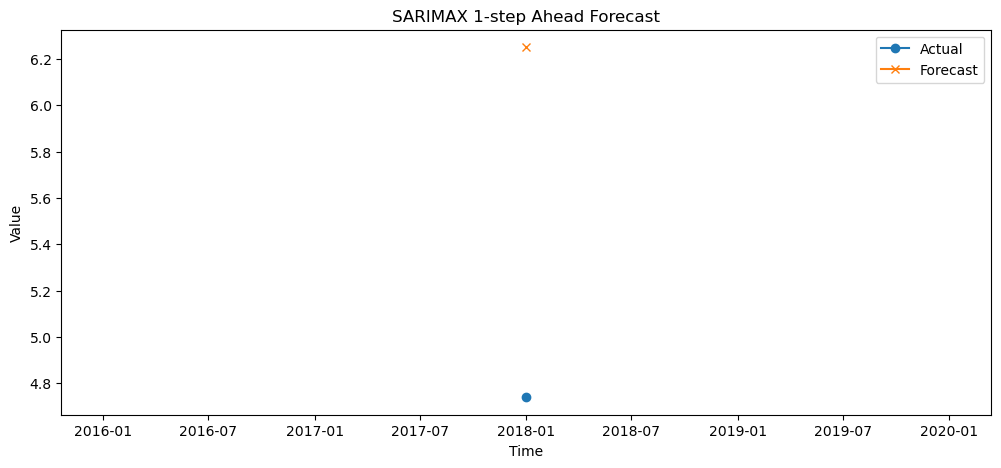

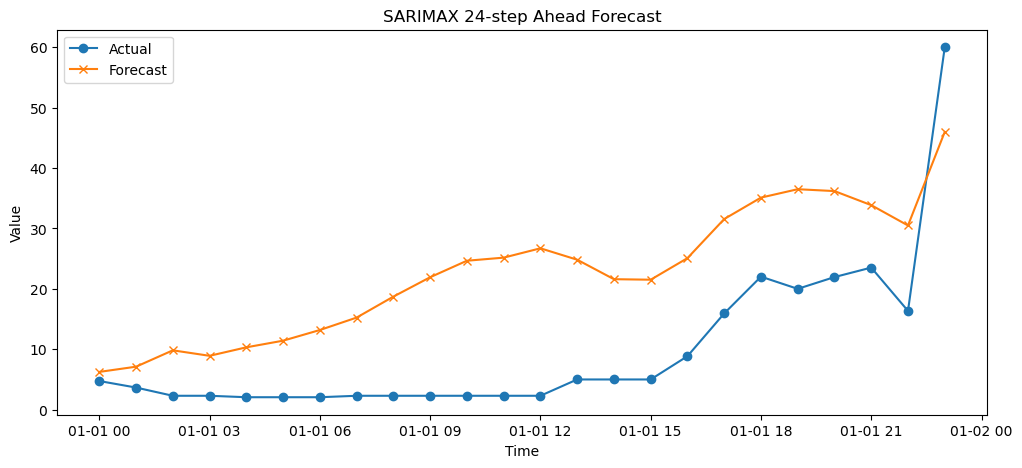

In [24]:
def plot_forecast(actual, forecast, title):
    plt.figure(figsize=(12,5))
    plt.plot(actual.index, actual, label='Actual', marker='o')
    plt.plot(forecast.index, forecast, label='Forecast', marker='x')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

# SARIMA Plots
plot_forecast(y_test.iloc[:1], sarima_forecast_1h, 'SARIMA 1-step Ahead Forecast')
plot_forecast(y_test.iloc[:24], sarima_forecast_24h, 'SARIMA 24-step Ahead Forecast')

# SARIMAX Plots
plot_forecast(y_test.iloc[:1], sarimax_forecast_1h, 'SARIMAX 1-step Ahead Forecast')
plot_forecast(y_test.iloc[:24], sarimax_forecast_24h, 'SARIMAX 24-step Ahead Forecast')

#### Machine Learning models

In order to train ML models, sliding-window datasets will be used. It will be made a comparison between the window sizes using a baseline_model to make the decision of which sliding-window will be used for 1 hour and 24 hours predictions.

In [29]:
def slideWindow(time_series, window_in, horizon):
    
    if (len(time_series) - window_in - horizon + 1) <= 0:
        raise ValueError("Time series too short for window size or horizon.")
        
    d = time_series.values
    X, y = [], []
    
    for start in range(len(time_series)-window_in):
        end = start + window_in
        out = end + horizon
        X.append(d[start:end].reshape(-1))
        y.append(d[end:out].ravel()) # ravel() is equivalent to reshape(-1): returns contiguous flattened array
    
    cols_x = [f'x{i}' for i in range(1, window_in+1)]
    cols_y = [f'y{i}' for i in range(1, horizon+1)]
    
    df_X = pd.DataFrame(X, columns=cols_x)
    df_y = pd.DataFrame(y, columns=cols_y)
    
    return pd.concat([df_X, df_y], axis=1).dropna()




In [30]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor

baseline_model = RandomForestRegressor(n_estimators=20, random_state=42)

window_sizes = [24, 48, 72]
window_scores = {}

for w in window_sizes:
    print('Window', w, '...')
    data = slideWindow(df['price_day_ahead'], w, horizon=1)
    X = data[[f'x{i}' for i in range(1, w+1)]]
    y = data['y1'].values  # flatten
    scores = cross_val_score(
        baseline_model, X, y,
        cv=TimeSeriesSplit(5),
        scoring='neg_root_mean_squared_error'
    )
    window_scores[w] = -scores.mean()

print(window_scores)

Window 24 ...
Window 48 ...
Window 72 ...
{24: np.float64(3.4192988346896036), 48: np.float64(3.450409982233663), 72: np.float64(3.382293461286826)}


Based on cross-validation results, both the 24-hour and 72-hour sliding windows achieve similarly low RMSE values, with only a minimal difference between them. Given that the 24-hour window uses fewer input features, it offers a simpler model that trains faster and focuses on the most recent, and likely most relevant, data patterns. Therefore, despite the marginally better RMSE of the 72-hour window, the 24-hour window is selected as the baseline for its balance of efficiency, simplicity, and comparable predictive performance.

In [60]:
window_sizes = [24, 48, 72, 96, 168]

for w in window_sizes:
    print('Window', w, '...')
    data = slideWindow(df['price_day_ahead'], w, horizon=24)
    X = data[[f'x{i}' for i in range(1, w+1)]]
    y = data['y1'].values  # flatten
    scores = cross_val_score(
        baseline_model, X, y,
        cv=TimeSeriesSplit(5),
        scoring='neg_root_mean_squared_error'
    )
    window_scores[w] = -scores.mean()

print(window_scores)

Window 24 ...
Window 48 ...
Window 72 ...
Window 96 ...
Window 168 ...
{24: np.float64(3.3984846685686705), 48: np.float64(3.4346478839727275), 72: np.float64(3.386416138354547), 96: np.float64(3.47805066536331), 168: np.float64(3.442905126651347)}


For the same reasons described above, for 24h forecasting, 24-hour window will be used to train the models on the next step.

In [66]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

window_in = 24
horizons = [1,24]  # 1-step ahead

tscv = TimeSeriesSplit(n_splits=5)

ML_models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Bagging": BaggingRegressor(n_estimators=50, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=50, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=50, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=50, random_state=42, verbosity=0),
    "LGBM": lgb.LGBMRegressor(n_estimators=50, random_state=42)
}

results = {}

for h in horizons:

    print('---------Models for', h, 'h predictions----------')
    # Create sliding-window dataset
    data = slideWindow(df['price_day_ahead'], window_in, h)
    X = data[[f'x{i}' for i in range(1, window_in+1)]].values
    y = data['y1'].values
    
    for name, model in ML_models.items():
        scores = cross_val_score(model, X, y, cv=tscv,
                                 scoring='neg_root_mean_squared_error',
                                 n_jobs=-1)  # parallelize
        results[name] = -scores.mean()
        print(f"{name}: RMSE = {results[name]:.3f}")

---------Models for 1 h predictions----------
LinearRegression: RMSE = 3.083
DecisionTree: RMSE = 4.764
KNN: RMSE = 5.256
SVR: RMSE = 4.978
Bagging: RMSE = 3.344
GradientBoosting: RMSE = 3.609
RandomForest: RMSE = 3.337
XGBoost: RMSE = 3.531
LGBM: RMSE = 3.409
---------Models for 24 h predictions----------
LinearRegression: RMSE = 3.084
DecisionTree: RMSE = 4.760
KNN: RMSE = 5.258
SVR: RMSE = 4.980
Bagging: RMSE = 3.355
GradientBoosting: RMSE = 3.613
RandomForest: RMSE = 3.339
XGBoost: RMSE = 3.535
LGBM: RMSE = 3.418


In [67]:
# # Commented due to long time execution

# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestRegressor

# window_in = 24
# horizon = 1  # predict next 24 hours
# tscv = TimeSeriesSplit(n_splits=5)

# data = slideWindow(df['price_day_ahead'], window_in, horizon)
# X = data[[f'x{i}' for i in range(1, window_in+1)]].values
# y = data[[f'y{i}' for i in range(1, horizon+1)]].values  # multi-output

# # -----------------------------
# # Define models and grids
# # -----------------------------
# models = {
#     "RandomForest": {
#         "estimator": RandomForestRegressor(random_state=42),
#         "param_grid": {
#             'n_estimators': [50, 100, 200],
#             'max_depth': [None, 5, 10, 20],
#             'min_samples_split': [2, 5],
#             'min_samples_leaf': [1, 2]
#         }
#     },
#     "GradientBoosting": {
#         "estimator": GradientBoostingRegressor(random_state=42),
#         "param_grid": {
#             'n_estimators': [50, 100, 200],
#             'learning_rate': [0.01, 0.05, 0.1],
#             'max_depth': [3, 5, 7],
#             'subsample': [0.6, 0.8, 1.0]
#         }
#     },
#     "XGBoost": {
#         "estimator": xgb.XGBRegressor(random_state=42, verbosity=0),
#         "param_grid": {
#             'n_estimators': [50, 100, 200],
#             'learning_rate': [0.01, 0.05, 0.1],
#             'max_depth': [3, 5, 7],
#             'subsample': [0.6, 0.8, 1.0]
#         }
#     },
#     "LGBM": {
#         "estimator": lgb.LGBMRegressor(random_state=42),
#         "param_grid": {
#             'n_estimators': [50, 100, 200],
#             'learning_rate': [0.01, 0.05, 0.1],
#             'num_leaves': [31, 50, 100],
#             'subsample': [0.6, 0.8, 1.0]
#         }
#     }
# }

# # -----------------------------
# # Grid Search with TimeSeriesSplit
# # -----------------------------
# best_models = {}

# for name, info in models.items():
#     print(f"----- Grid Search for {name} -----")
    
#     grid = GridSearchCV(
#         estimator=info['estimator'],
#         param_grid=info['param_grid'],
#         cv=tscv,
#         scoring='neg_root_mean_squared_error',
#         n_jobs=-1,
#         verbose=2
#     )
    
#     grid.fit(X, y)
    
#     print(f"Best params for {name}: {grid.best_params_}")
#     print(f"Best CV RMSE: {-grid.best_score_:.3f}\n")
    
#     best_models[name] = grid.best_estimator_


----- Grid Search for RandomForest -----
Fitting 5 folds for each of 48 candidates, totalling 240 fits


C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best params for RandomForest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE: 3.285

----- Grid Search for GradientBoosting -----
Fitting 5 folds for each of 81 candidates, totalling 405 fits


C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Best params for GradientBoosting: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE: 3.360

----- Grid Search for XGBoost -----
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params for XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.6}
Best CV RMSE: 3.395

----- Grid Search for LGBM -----
Fitting 5 folds for each of 81 candidates, totalling 405 fits


C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002479 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 35040, number of used features: 24
[LightGBM] [Info] Start training from score 49.876514
Best params for LGBM: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 50, 'subsample': 0.6}
Best CV RMSE: 3.341



----- Grid Search for RandomForest -----
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best params for RandomForest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best CV RMSE: 3.285

----- Grid Search for GradientBoosting -----

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best params for GradientBoosting: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Best CV RMSE: 3.360

----- Grid Search for XGBoost -----

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best params for XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.6}

Best CV RMSE: 3.395

----- Grid Search for LGBM -----

Fitting 5 folds for each of 81 candidates, totalling 405 fits

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002479 seconds.

You can set `force_col_wise=true` to remove the overhead.

[LightGBM] [Info] Total Bins 6120

[LightGBM] [Info] Number of data points in the train set: 35040, number of used features: 24

[LightGBM] [Info] Start training from score 49.876514

Best params for LGBM: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 50, 'subsample': 0.6}

Best CV RMSE: 3.341

In [26]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

gb_final = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

xgb_final = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.6,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

lgbm_final = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=50,
    subsample=0.6,
    random_state=42,
    n_jobs=-1
)


best_models = {
    "RandomForest": rf_final,
    "GradientBoosting": gb_final,
    "XGBoost": xgb_final,
    "LGBM": lgbm_final
}

In [39]:
from sklearn.preprocessing import MinMaxScaler

window_in = 24
horizon_1h = 1
horizon_24h = 24

# --- Sliding-window datasets ---
train_1h = slideWindow(train['price_day_ahead'], window_in, horizon_1h)
X_train_1h = train_1h[[f'x{i}' for i in range(1, window_in+1)]].values
y_train_1h = train_1h['y1'].values

train_24h = slideWindow(train['price_day_ahead'], window_in, horizon_24h)
X_train_24h = train_24h[[f'x{i}' for i in range(1, window_in+1)]].values
y_train_24h = train_24h[[f'y{i}' for i in range(1, horizon_24h+1)]].values

# --- Scalers ---
scaler_1h = MinMaxScaler()
X_train_scaled_1h = scaler_1h.fit_transform(X_train_1h)

scaler_24h = MinMaxScaler()
X_train_scaled_24h = scaler_24h.fit_transform(X_train_24h)


In [40]:
# LONG TIME EXECUTION (~ 1 hour)

models_1h = {}
models_24h = {}

from sklearn.multioutput import MultiOutputRegressor

for name, model in best_models.items():
    # 1-hour ahead
    m1 = model.__class__(**model.get_params())
    m1.fit(X_train_scaled_1h, y_train_1h)
    models_1h[name] = m1

    # 24-hour ahead
    if name == "RandomForest":
        # RF supports multi-output natively
        m24 = model.__class__(**model.get_params())
    else:
        # Wrap others
        m24 = MultiOutputRegressor(
            model.__class__(**model.get_params())
        )

    m24.fit(X_train_scaled_24h, y_train_24h)
    models_24h[name] = m24


# --- Prepare test input ---
last_24h_train = train['price_day_ahead'].iloc[-window_in:]
X_test_init = last_24h_train.values.reshape(1, -1)

# --- Scale test input ---
X_test_scaled_1h = scaler_1h.transform(X_test_init)
X_test_scaled_24h = scaler_24h.transform(X_test_init)

# --- 1-hour predictions ---
pred_1h = {}
true_1h = y_test.iloc[0]

for name, model in models_1h.items():
    pred_1h[name] = float(model.predict(X_test_scaled_1h)[0])

# --- 24-hour predictions ---
pred_24h = {}
true_24h = y_test.iloc[:24].values

for name, model in models_24h.items():
    pred_24h[name] = model.predict(X_test_scaled_24h).ravel()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001719 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 26281, number of used features: 24
[LightGBM] [Info] Start training from score 47.402486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 26258, number of used features: 24
[LightGBM] [Info] Start training from score 47.431015
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 26258, number of used features: 24
[LightGBM] [Info] Start t

C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\jorge\anaconda3\Lib\site-packag

In [41]:
df_1h_compare = pd.DataFrame({
    'True': [true_1h],
    **pred_1h
})

df_1h_compare

,True,RandomForest,GradientBoosting,XGBoost,LGBM
0,4.74,6.177308,5.598017,6.508994,4.822012


In [45]:
df_24h_compare = pd.DataFrame(
    pred_24h,
    index=y_test.index[:24]
)

df_24h_compare['True'] = true_24h

df_24h_compare

,RandomForest,GradientBoosting,XGBoost,LGBM,True
time,,,,,
2018-01-01 00:00:00+00:00,7.373219,5.242094,5.886302,5.036063,4.74
2018-01-01 01:00:00+00:00,7.327239,4.566674,6.939247,5.226254,3.66
2018-01-01 02:00:00+00:00,7.744603,5.078564,8.433393,7.027515,2.30
2018-01-01 03:00:00+00:00,9.025351,6.428104,6.513278,8.008237,2.30
2018-01-01 04:00:00+00:00,10.927669,9.843280,10.490593,8.699456,2.06
2018-01-01 05:00:00+00:00,12.979767,13.157899,14.960390,12.842674,2.06
2018-01-01 06:00:00+00:00,14.603038,15.480485,16.675570,18.388604,2.06
2018-01-01 07:00:00+00:00,15.591886,18.745133,19.978849,19.945811,2.30
2018-01-01 08:00:00+00:00,16.242664,20.720540,20.376604,20.083243,2.30


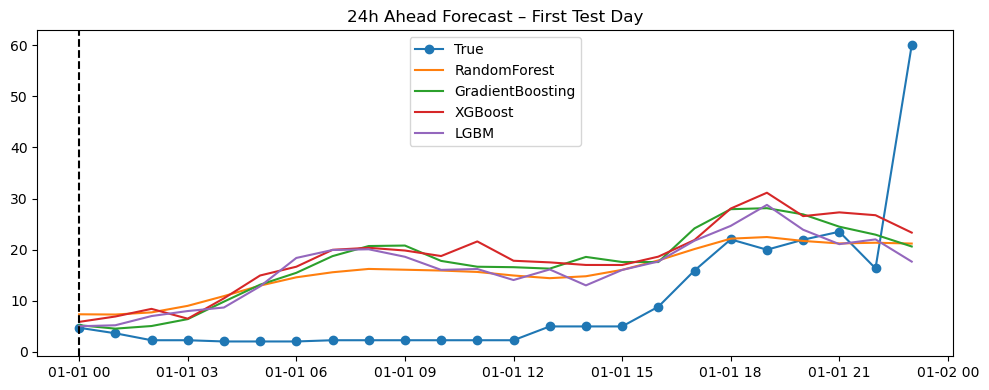

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.index[:24], true_24h, label="True", marker='o')

for name, pred in pred_24h.items():
    plt.plot(y_test.index[:24], pred, label=name)

plt.axvline(y_test.index[0], color='k', linestyle='--')
plt.title("24h Ahead Forecast – First Test Day")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
models.update(best_models)
len(models)

6

In [48]:
print(models)

{'SARIMA': <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper object at 0x0000023A39D2DE00>, 'SARIMAX': <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper object at 0x0000023A39D2F950>, 'RandomForest': RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, n_estimators=200,
                      n_jobs=-1, random_state=42), 'GradientBoosting': GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200,
                          random_state=42, subsample=0.8), 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
          

#### Deep Learning models

Initially, a copy of the original dataframe is created and the observations are ordered by the datetime index to ensure a correct chronological sequence.

The dataset is then split in a temporal manner, using data **from 2015 to 2017** for **training** and reserving the entire year of **2018** for **testing**. This separation guarantees that the model is trained exclusively on past data and evaluated on future, unseen observations.

If no data are found in either period, an error is raised to prevent invalid model training or evaluation.

The printed date ranges confirm that the *training* set spans from *2015-01-01 to 2017-12-31*, while the *test* set covers *2018-01-01 to 2018-12-31*. This approach avoids any form of data leakage and ensures a realistic forecasting scenario, where predictions are made strictly using information available prior to the forecast horizon.

In [ ]:
df_DL = df.copy()

df_DL.index = pd.to_datetime(df_DL.index, utc=True, errors='coerce')
df_DL = df_DL[~df_DL.index.isna()]

# ordenar por índice
df_DL = df_DL.sort_index()

# split 
train_df = df_DL.loc['2015-01-01':'2017-12-31'].copy()
test_df  = df_DL.loc['2018-01-01':'2018-12-31'].copy()

if train_df.empty:
    raise ValueError("Não há dados entre 2015-2017.")
if test_df.empty:
    raise ValueError("Não há dados em 2018.")

print("Train:", train_df.index.min(), "->", train_df.index.max(), train_df.shape)
print("Test :", test_df.index.min(),  "->", test_df.index.max(),  test_df.shape)


Train: 2015-01-01 00:00:00+00:00 -> 2017-12-31 23:00:00+00:00 (26304, 20)
Test : 2018-01-01 00:00:00+00:00 -> 2018-12-31 22:00:00+00:00 (8759, 20)


The next section builds supervised learning samples from a *1D time series* using a *sliding window*, each input *X* contains the last **WINDOW_IN=24** values, and each target *y* contains the next **HORIZON value(s)**.

It runs two scenarios, **HORIZON=1** (predict 1 step ahead) and **HORIZON=24** (predict the next 24 steps), with checks to ensure the train/test series are long enough and that the windowing actually produces data.
The shapes match the logic, for **HORIZON=1** we get *y* with shape (n_samples, 1), and for **HORIZON=24** *y* with shape (n_samples, 24).

In [28]:
def slideWindow(time_series, window_in, horizon):
    X, y = [], []
    for i in range(len(time_series) - window_in - horizon + 1):
        X.append(time_series[i:i + window_in])
        y.append(time_series[i + window_in:i + window_in + horizon])
    return np.array(X), np.array(y)


# dados
series_train = train_df['price_day_ahead'].dropna().values
series_test  = test_df['price_day_ahead'].dropna().values

WINDOW_IN = 24

# correr os dois cenários
results = {}

for HORIZON in [1, 24]:

    if len(series_train) < WINDOW_IN + HORIZON:
        raise ValueError(
            f"A série de treino é muito curta ({len(series_train)} amostras) para WINDOW_IN={WINDOW_IN}, HORIZON={HORIZON}."
        )

    if len(series_test) < WINDOW_IN + HORIZON:
        raise ValueError(
            f"A série de teste é muito curta ({len(series_test)} amostras) para WINDOW_IN={WINDOW_IN}, HORIZON={HORIZON}."
        )

    X_train_full, y_train_full = slideWindow(series_train, WINDOW_IN, HORIZON)
    X_test, y_test             = slideWindow(series_test,  WINDOW_IN, HORIZON)

    if len(X_train_full) == 0 or len(y_train_full) == 0:
        raise ValueError(f"A slideWindow não gerou dados no TREINO para HORIZON={HORIZON}.")

    if len(X_test) == 0 or len(y_test) == 0:
        raise ValueError(f"A slideWindow não gerou dados no TESTE para HORIZON={HORIZON}.")

    print(f"HORIZON={HORIZON} -> Train:", X_train_full.shape, y_train_full.shape,
          "| Test:", X_test.shape, y_test.shape)

    results[HORIZON] = (X_train_full, y_train_full, X_test, y_test)


HORIZON=1 -> Train: (26280, 24) (26280, 1) | Test: (8735, 24) (8735, 1)
HORIZON=24 -> Train: (26257, 24) (26257, 24) | Test: (8712, 24) (8712, 24)


After generating the sliding windows, we prepared the data for the *DL models* for two forecasting tasks: **HORIZON=1** and **HORIZON=24**.

- First, it was created *input–output pairs* with slideWindow: X has 24 past values and y has the next 1 or next 24 values.
- Then, it splits the training windows into 80% train and 20% validation (used to tune/early-stop), and checks that none of the splits are empty.
- Next, it scales the inputs with **MinMaxScaler** fitted only on **X_train**, applies the same transformation to **X_val/X_test**, and **reshapes back to 3D** *(samples, timesteps, 1)* because **GRU** and **LSTM** expect that format.
- For the targets, it fits *scaler_y* only on **y_train (flattened to 2D)**, then transforms **y_train/y_val/y_test** and **reshapes back** so shapes stay consistent for both horizons.

The printed results confirm this: for **HORIZON=1, y is (N,1)**, for **HORIZON=24, y is (N,24)**, and the sample counts differ slightly because longer horizons reduce the number of valid windows.

In [29]:
results_prepared = {}

for HORIZON in [1, 24]:

    #  janelas
    X_train_full, y_train_full = slideWindow(series_train, WINDOW_IN, HORIZON)
    X_test, y_test = slideWindow(series_test,  WINDOW_IN, HORIZON)

    # dividir o treino em treino + validação 
    train_size = int(len(X_train_full) * 0.80)
    val_size   = len(X_train_full) - train_size

    if train_size == 0 or val_size == 0 or len(X_test) == 0:
        raise ValueError(
            f"Amostras insuficientes. train_full={len(X_train_full)}, val={val_size}, test={len(X_test)}"
        )

    X_train = X_train_full[:train_size]
    X_val   = X_train_full[train_size:]
    y_train = y_train_full[:train_size]
    y_val   = y_train_full[train_size:]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()


    # garantir que X está em 2D para o scaler (N, WINDOW_IN)
    if X_train.ndim == 3:
        X_train_2d = X_train.reshape(X_train.shape[0], X_train.shape[1])
        X_val_2d   = X_val.reshape(X_val.shape[0], X_val.shape[1])
        X_test_2d  = X_test.reshape(X_test.shape[0], X_test.shape[1])
    else:
        X_train_2d = X_train
        X_val_2d   = X_val
        X_test_2d  = X_test

    X_train_2d = scaler_X.fit_transform(X_train_2d)
    X_val_2d   = scaler_X.transform(X_val_2d)
    X_test_2d  = scaler_X.transform(X_test_2d)

    # voltar a 3D: (samples, timesteps, features=1)
    X_train = X_train_2d.reshape(X_train_2d.shape[0], X_train_2d.shape[1], 1)
    X_val   = X_val_2d.reshape(X_val_2d.shape[0], X_val_2d.shape[1], 1)
    X_test  = X_test_2d.reshape(X_test_2d.shape[0],  X_test_2d.shape[1],  1)

    # y: serve para HORIZON=1 e HORIZON=24
    y_train_shape = y_train.shape
    y_val_shape   = y_val.shape
    y_test_shape  = y_test.shape

    scaler_y.fit(y_train.reshape(-1, 1))

    y_train = scaler_y.transform(y_train.reshape(-1, 1)).reshape(y_train_shape)
    y_val   = scaler_y.transform(y_val.reshape(-1, 1)).reshape(y_val_shape)
    y_test  = scaler_y.transform(y_test.reshape(-1, 1)).reshape(y_test_shape)

    print(f" HORIZON={HORIZON}")
    print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}")

    # guardar tudo para treinar depois
    results_prepared[HORIZON] = {
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val,     "y_val": y_val,
        "X_test": X_test,   "y_test": y_test,
        "scaler_X": scaler_X, "scaler_y": scaler_y
    }


 HORIZON=1
X_train: (21024, 24, 1), X_val: (5256, 24, 1), X_test: (8735, 24, 1)
y_train: (21024, 1), y_val: (5256, 1), y_test: (8735, 1)
 HORIZON=24
X_train: (21005, 24, 1), X_val: (5252, 24, 1), X_test: (8712, 24, 1)
y_train: (21005, 24), y_val: (5252, 24), y_test: (8712, 24)


Next, **hyperparameter tuning** is performed for the *GRU* and *LSTM* models using a **time-aware cross-validation strategy**. Two forecasting *horizons* are considered (1 and 24 hours) to evaluate both short and medium-term predictions.

For each model and horizon, several configurations are tested, and the **best-performing parameters** are selected based on the *mean squared error*. This approach ensures that models are trained on past data and evaluated on future observations, avoiding information leakage and enabling a fair comparison between architectures.

In [ ]:
# Scorer
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Optimizer helper
def get_optimizer(name, lr=0.001):
    if name.lower() == "rmsprop":
        return RMSprop(learning_rate=lr)
    elif name.lower() == "adam":
        return Adam(learning_rate=lr)
    else:
        raise ValueError(f"Optimizer '{name}' não suportado.")

# Model factory (GRU ou LSTM)
def create_model(model_type, input_shape, horizon, latent_dim, dropout_rate, optimizer_name):
    model = Sequential()
    model.add(Input(shape=input_shape))

    if model_type == "GRU":
        model.add(GRU(latent_dim))
    elif model_type == "LSTM":
        model.add(LSTM(latent_dim))
    else:
        raise ValueError("model_type deve ser 'GRU' ou 'LSTM'")

    model.add(Dropout(dropout_rate))
    model.add(Dense(horizon))

    model.compile(
        optimizer=get_optimizer(optimizer_name),
        loss="mse"
    )
    return model

# Wrapper genérico para GridSearch
class KerasRNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        model_type="GRU",
        horizon=1,
        latent_dim=5,
        optimizer="RMSprop",
        dropout_rate=0.2,
        batch_size=32,
        epochs=10
    ):
        self.model_type = model_type
        self.horizon = horizon
        self.latent_dim = latent_dim
        self.optimizer = optimizer
        self.dropout_rate = dropout_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.model = None

    def fit(self, X, y):
        X = X.reshape(X.shape[0], X.shape[1], 1) if X.ndim == 2 else X
        input_shape = (X.shape[1], X.shape[2])

        self.model = create_model(
            model_type=self.model_type,
            input_shape=input_shape,
            horizon=self.horizon,
            latent_dim=self.latent_dim,
            dropout_rate=self.dropout_rate,
            optimizer_name=self.optimizer
        )

        earlystop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        self.model.fit(
            X, y,
            batch_size=self.batch_size,
            epochs=self.epochs,
            validation_split=0.2,
            callbacks=[earlystop],
            verbose=0,
            shuffle=False
        )
        return self

    def predict(self, X):
        X = X.reshape(X.shape[0], X.shape[1], 1) if X.ndim == 2 else X
        return self.model.predict(X, verbose=0)

# Parameter grid
param_grid = {
    "latent_dim": [5, 10, 20],
    "optimizer": ["RMSprop", "adam"],
    "dropout_rate": [0.2, 0.3],
    "batch_size": [16, 32],
    "epochs": [10, 20]
}

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

# GridSearch — GRU & LSTM | H = 1 e 24
best_params = {}

for HORIZON in [1, 24]:

    X_train = results_prepared[HORIZON]["X_train"]
    y_train = results_prepared[HORIZON]["y_train"]

    for model_type in ["GRU", "LSTM"]:

        print(f"\n GridSearch — {model_type}, H={HORIZON}")

        estimator = KerasRNNRegressor(
            model_type=model_type,
            horizon=HORIZON
        )

        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=tscv,
            scoring=neg_mse_scorer,
            verbose=2,
            n_jobs=1,
            error_score="raise"
        )

        grid_result = grid.fit(X_train, y_train)

        best_params[(model_type, HORIZON)] = grid_result.best_params_

        print(f"\n Best parameters ({model_type}, H={HORIZON}):")
        print(grid_result.best_params_)


This section defines the *final training setup* using the best hyperparameters obtained previously. The selected **GRU** and **LSTM** model is trained with *early stopping* to prevent **overfitting** and evaluated for a chosen forecasting horizon. 

After training, the model is used to generate predictions on the test set, preserving the temporal order of the data.

In [30]:
# Best params do GridSearch
best_params = {
    ("GRU", 1):  {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 20, 'latent_dim': 10, 'optimizer': 'RMSprop'},
    ("LSTM", 1): {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 20, 'latent_dim': 20, 'optimizer': 'RMSprop'},
    ("GRU", 24): {'batch_size': 32, 'dropout_rate': 0.2, 'epochs': 20, 'latent_dim': 10, 'optimizer': 'adam'},
    ("LSTM", 24):{'batch_size': 32, 'dropout_rate': 0.2, 'epochs': 20, 'latent_dim': 5,  'optimizer': 'adam'}
}


# ESCOLHER CENÁRIO
MODEL_TYPE = "GRU"  
HORIZON = 1       

# Extrair parâmetros corretos
params = best_params[(MODEL_TYPE, HORIZON)]

LATENT_DIM     = params['latent_dim']
BATCH_SIZE     = params['batch_size']
EPOCHS         = params['epochs']
DROPOUT_RATE   = params['dropout_rate']
OPTIMIZER_NAME = params['optimizer']


# Early stopping
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Optimizer helper
def get_optimizer(name, lr=0.001):
    if name.lower() == 'rmsprop':
        return RMSprop(learning_rate=lr)
    elif name.lower() == 'adam':
        return Adam(learning_rate=lr)
    else:
        raise ValueError("Optimizer não suportado")

# Model builders
def create_gru_model_1(input_shape, horizon=HORIZON):
    model = Sequential([
        GRU(LATENT_DIM, input_shape=input_shape),
        Dropout(DROPOUT_RATE),
        Dense(horizon)
    ])
    model.compile(
        optimizer=get_optimizer(OPTIMIZER_NAME),
        loss='mse'
    )
    return model


def create_lstm_model_1(input_shape, horizon=HORIZON):
    model = Sequential([
        LSTM(LATENT_DIM, input_shape=input_shape),
        Dropout(DROPOUT_RATE),
        Dense(horizon)
    ])
    model.compile(
        optimizer=get_optimizer(OPTIMIZER_NAME),
        loss='mse'
    )
    return model

# Dados 
X_train = results_prepared[HORIZON]["X_train"]
y_train = results_prepared[HORIZON]["y_train"]
X_val   = results_prepared[HORIZON]["X_val"]
y_val   = results_prepared[HORIZON]["y_val"]
X_test  = results_prepared[HORIZON]["X_test"]
y_test  = results_prepared[HORIZON]["y_test"]


# Criar modelo correto
if MODEL_TYPE == "GRU":
    model = create_gru_model_1(input_shape=X_train.shape[1:], horizon=HORIZON)
elif MODEL_TYPE == "LSTM":
    model = create_lstm_model_1(input_shape=X_train.shape[1:], horizon=HORIZON)
else:
    raise ValueError("MODEL_TYPE inválido")

model.summary()

# Treino
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[earlystop],
    verbose=1,
    shuffle=False
)

# Previsão
y_pred = model.predict(X_test, verbose=0)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 10)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0076 - val_loss: 0.0017
Epoch 2/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 3/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0019 - val_loss: 0.0010
Epoch 4/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 5/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 6/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 7/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 8/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 9/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 10/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 11/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 12/20
1314/1314 ━

The **GRU model** exhibits *fast* and *stable convergence* during *training*. 

The *training loss* decreases sharply in the first epochs, **dropping from approximately 0.010 to around 0.002**, which indicates that the model *quickly captures the main temporal patterns in the data*.

The *validation loss* follows a consistent downward trend and *remains slightly lower than the training loss* throughout the training process. This behaviour suggests *good generalization performance* and *no evidence of overfitting*. 

The model has a compact architecture with a limited number of trainable parameters, which is appropriate for the dataset size and contributes to controlling model complexity.

Overall, the loss curves indicate that the **GRU model** is well suited for *one-step-ahead forecasting*

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 10)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0105 - val_loss: 0.0018
Epoch 2/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 3/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 4/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 5/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0020 - val_loss: 0.0010


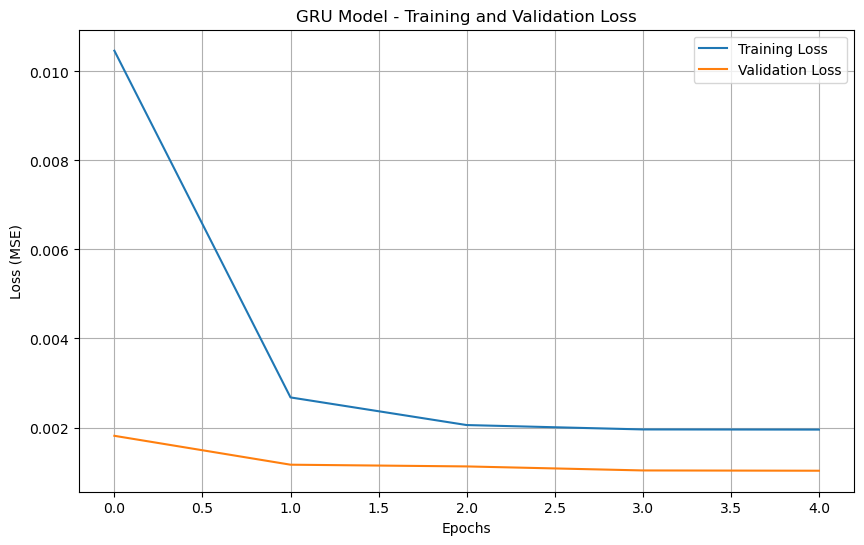

In [31]:
gru_model = create_gru_model_1(
    input_shape=X_train.shape[1:], 
    horizon=HORIZON
)

gru_model.summary()

gru_model_history = gru_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[earlystop],
    verbose=1,
    shuffle=False
)

y_pred_gru = gru_model.predict(X_test, verbose=0)

plt.figure(figsize=(10, 6))
plt.plot(gru_model_history.history['loss'], label='Training Loss')
plt.plot(gru_model_history.history['val_loss'], label='Validation Loss')
plt.title('GRU Model - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid()
plt.show()


The **LSTM model** also shows stable and consistent learning behaviour for the **one-step-ahead** forecasting task. 

The *training loss* decreases rapidly in the first epochs, **dropping from approximately 0.011 to around 0.002**.

The *validation loss* follows a smooth downward trend and remains consistently lower than the training loss, suggesting good generalization performance and no signs of overfitting. The absence of large oscillations in the validation curve indicates that the selected hyperparameters and regularization strategy are appropriate.

Although the LSTM model has slightly more trainable parameters than the GRU, it converges quickly and reaches a low validation error within a few epochs.

Overall, the loss curves confirm that the LSTM is well suited for one-step-ahead forecasting, achieving reliable convergence and effective generalization, with early stopping preventing unnecessary training beyond the optimal point.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0109 - val_loss: 0.0032
Epoch 2/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0040 - val_loss: 0.0015
Epoch 3/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 4/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 5/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0020 - val_loss: 0.0011


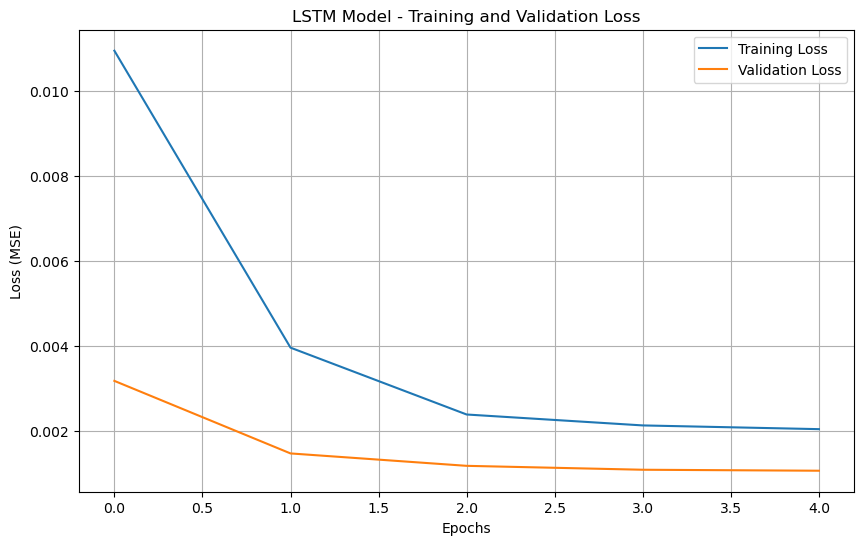

In [32]:
# LSTM — One-step forecasting
# Criar o modelo LSTM com os melhores parâmetros
lstm_model = create_lstm_model_1(
    input_shape=X_train.shape[1:], 
    horizon=HORIZON
)

lstm_model.summary()

# Treino do modelo
lstm_model_history = lstm_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[earlystop],
    verbose=1,
    shuffle=False
)

y_pred_lstm = lstm_model.predict(X_test, verbose=0)


# Curvas de loss (treino vs validação)
plt.figure(figsize=(10, 6))
plt.plot(lstm_model_history.history['loss'], label='Training Loss')
plt.plot(lstm_model_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid()
plt.show()


The **quantitative results** show a *clear performance difference between the two models*. 

The **GRU** achieves *lower error values across all metrics* (MAE = 3.21, RMSE = 4.43, MAPE = 8.95%) compared to the **LSTM**, which *presents higher errors* (MAE = 5.11, RMSE = 6.40, MAPE = 13.54%). These results indicate that, on average, the GRU produces predictions that are closer to the true values and more reliable in relative terms.

This difference is also evident in the prediction plot. The GRU predictions closely follow the true series, capturing both the overall trend and most short-term fluctuations. In contrast, the LSTM predictions appear smoother and tend to deviate more from the true values, particularly around sharp peaks and sudden drops, which explains its higher MAE and RMSE.

Both models show some difficulty in fully capturing extreme price variations, but this effect is more pronounced for the LSTM, leading to larger relative errors, as reflected by its higher MAPE. Overall, the visual inspection of the forecasts is consistent with the numerical evaluation.

In summary, for one-step-ahead forecasting, **the GRU model outperforms the LSTM**, providing more accurate predictions and better tracking of short-term dynamics in the electricity price series.


Avaliação GRU (One-Step, H=1) [escala original]:
MAE = 3.2113, RMSE = 4.4287, MAPE = 8.95%

Avaliação LSTM (One-Step, H=1) [escala original]:
MAE = 5.1062, RMSE = 6.3973, MAPE = 13.54%


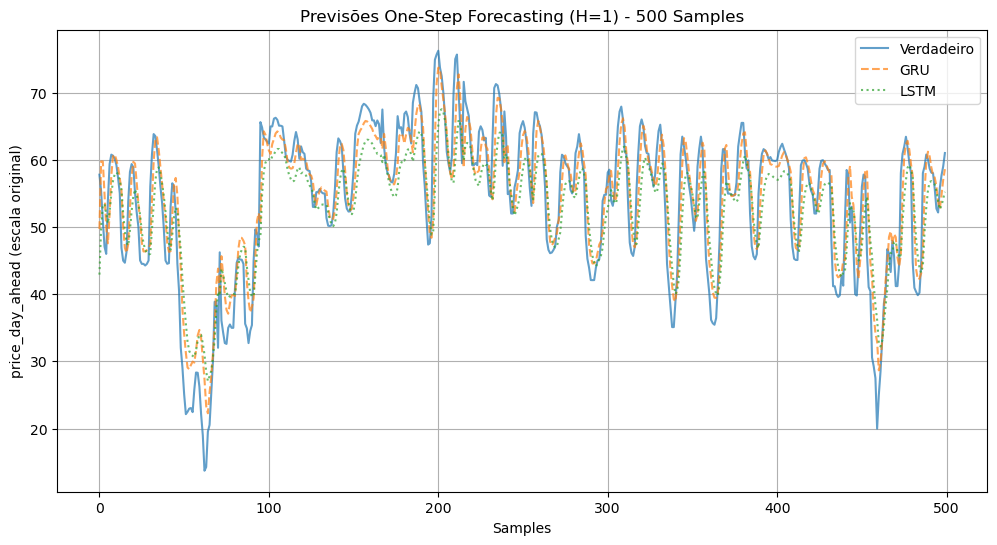

In [33]:
# ir buscar o scaler_y usado na preparação (H=1)
scaler_y = results_prepared[HORIZON]["scaler_y"]

# garantir shapes (N,1)
if y_pred_gru.ndim == 1:
    y_pred_gru = y_pred_gru.reshape(-1, 1)
if y_pred_lstm.ndim == 1:
    y_pred_lstm = y_pred_lstm.reshape(-1, 1)
if y_test.ndim == 1:
    y_test = y_test.reshape(-1, 1)

# voltar à escala original
y_test_inv      = scaler_y.inverse_transform(y_test)
y_pred_gru_inv  = scaler_y.inverse_transform(y_pred_gru)
y_pred_lstm_inv = scaler_y.inverse_transform(y_pred_lstm)

# === igual ao que mandaste ===
y_pred_gru_one_step  = y_pred_gru_inv[:, 0]   # Extrair o primeiro passo
y_pred_lstm_one_step = y_pred_lstm_inv[:, 0]
y_test_one_step      = y_test_inv[:, 0]

# Avaliar previsões para One-Step Forecasting
def evaluate_one_step(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
    return mae, rmse, mape

gru_mae, gru_rmse, gru_mape   = evaluate_one_step(y_test_one_step, y_pred_gru_one_step)
lstm_mae, lstm_rmse, lstm_mape = evaluate_one_step(y_test_one_step, y_pred_lstm_one_step)

print("\nAvaliação GRU (One-Step, H=1) [escala original]:")
print(f"MAE = {gru_mae:.4f}, RMSE = {gru_rmse:.4f}, MAPE = {gru_mape:.2f}%")

print("\nAvaliação LSTM (One-Step, H=1) [escala original]:")
print(f"MAE = {lstm_mae:.4f}, RMSE = {lstm_rmse:.4f}, MAPE = {lstm_mape:.2f}%")

# Plot (quase igual ao teu)
num_samples = 500
n = min(num_samples, len(y_test_one_step))

plt.figure(figsize=(12, 6))
plt.plot(y_test_one_step[:n], label="Verdadeiro", alpha=0.7)
plt.plot(y_pred_gru_one_step[:n], label="GRU", linestyle="--", alpha=0.7)
plt.plot(y_pred_lstm_one_step[:n], label="LSTM", linestyle=":", alpha=0.7)
plt.legend()
plt.title(f"Previsões One-Step Forecasting (H=1) - {n} Samples")
plt.xlabel("Samples")
plt.ylabel("price_day_ahead (escala original)")
plt.grid()
plt.show()


In [34]:
MODEL_TYPE = "GRU"  
HORIZON = 24

# Best params do GridSearch (H=24)
best_params = {
    "GRU":  {'batch_size': 32, 'dropout_rate': 0.2, 'epochs': 20, 'latent_dim': 10, 'optimizer': 'adam'},
    "LSTM": {'batch_size': 32, 'dropout_rate': 0.2, 'epochs': 20, 'latent_dim': 5,  'optimizer': 'adam'}
}

params = best_params[MODEL_TYPE]

LATENT_DIM     = params['latent_dim']
BATCH_SIZE     = params['batch_size']
EPOCHS         = params['epochs']
DROPOUT_RATE   = params['dropout_rate']
OPTIMIZER_NAME = params['optimizer']

# Early stopping
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Optimizer helper
def get_optimizer(name, lr=0.001):
    if name.lower() == 'rmsprop':
        return RMSprop(learning_rate=lr)
    elif name.lower() == 'adam':
        return Adam(learning_rate=lr)
    else:
        raise ValueError("Optimizer não suportado")

# Model builders (H=24)
def create_gru_model_24(input_shape, horizon=HORIZON):
    model = Sequential([
        GRU(LATENT_DIM, input_shape=input_shape),
        Dropout(DROPOUT_RATE),
        Dense(horizon)
    ])
    model.compile(
        optimizer=get_optimizer(OPTIMIZER_NAME),
        loss='mse'
    )
    return model


def create_lstm_model_24(input_shape, horizon=HORIZON):
    model = Sequential([
        LSTM(LATENT_DIM, input_shape=input_shape),
        Dropout(DROPOUT_RATE),
        Dense(horizon)
    ])
    model.compile(
        optimizer=get_optimizer(OPTIMIZER_NAME),
        loss='mse'
    )
    return model

# Dados (H=24)
X_train = results_prepared[HORIZON]["X_train"]
y_train = results_prepared[HORIZON]["y_train"]
X_val   = results_prepared[HORIZON]["X_val"]
y_val   = results_prepared[HORIZON]["y_val"]
X_test  = results_prepared[HORIZON]["X_test"]
y_test  = results_prepared[HORIZON]["y_test"]

# Criar modelo correto
if MODEL_TYPE == "GRU":
    model = create_gru_model_24(input_shape=X_train.shape[1:], horizon=HORIZON)
elif MODEL_TYPE == "LSTM":
    model = create_lstm_model_24(input_shape=X_train.shape[1:], horizon=HORIZON)
else:
    raise ValueError("MODEL_TYPE inválido")

model.summary()

# Treino
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[earlystop],
    verbose=1,
    shuffle=False
)

# Previsão
y_pred = model.predict(X_test, verbose=0)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 10)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654 (2.55 KB)

 Trainable params: 654 (2.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0363 - val_loss: 0.0106
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0153 - val_loss: 0.0096
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0134 - val_loss: 0.0093
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0125 - val_loss: 0.0091
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0120 - val_loss: 0.0090
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0117 - val_loss: 0.0089
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0115 - val_loss: 0.0088
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0113 - val_loss: 0.0088
Epoch 9/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0113 - val_loss: 0.0086
Epoch 10/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0112 - val_loss: 0.0085
Epoch 11/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0111 - val_loss: 0.0086
Epoch 12/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/st

For the **24-step-ahead forecasting** task (H = 24), the **GRU model** shows a stable and well-behaved training process. 

The *training loss* decreases sharply in the first epochs **(from approximately 0.038 to around 0.016)** and then continues to decrease more gradually, indicating effective learning of longer-term temporal dependencies.

The *validation loss* follows a similar downward trend and remains consistently lower than the training loss throughout training. This gap suggests good generalization and no signs of overfitting, despite the increased difficulty of the multi-step forecasting task. 

Overall, the loss curves indicate that the GRU model is able to handle the increased complexity of 24-hour-ahead forecasting, converging reliably and maintaining stable generalization performance.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 10)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24)             │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654 (2.55 KB)

 Trainable params: 654 (2.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0378 - val_loss: 0.0115
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0159 - val_loss: 0.0102
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0139 - val_loss: 0.0095
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0129 - val_loss: 0.0096
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0123 - val_loss: 0.0090


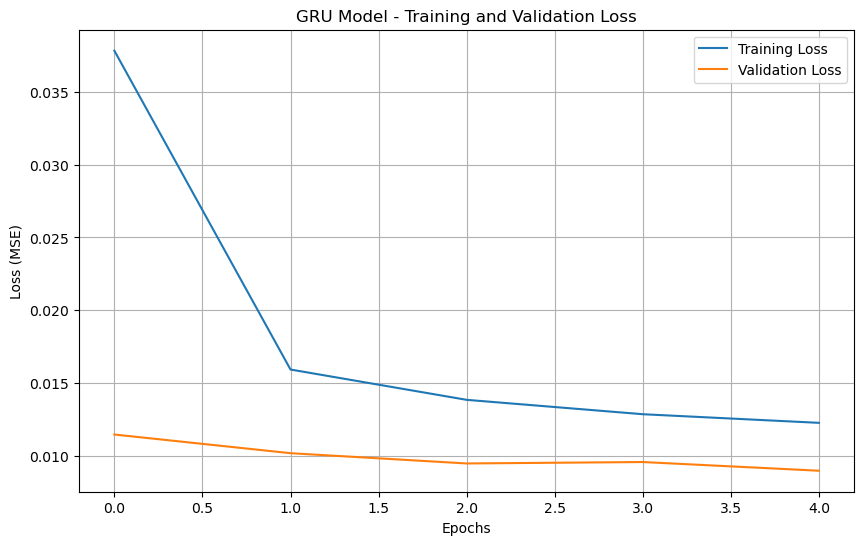

In [35]:
gru_model = create_gru_model_24(
    input_shape=X_train.shape[1:], 
    horizon=HORIZON
)

gru_model.summary()

gru_model_history = gru_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[earlystop],
    verbose=1,
    shuffle=False
)

y_pred_gru = gru_model.predict(X_test, verbose=0)

plt.figure(figsize=(10, 6))
plt.plot(gru_model_history.history['loss'], label='Training Loss')
plt.plot(gru_model_history.history['val_loss'], label='Validation Loss')
plt.title('GRU Model - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid()
plt.show()


The **LSTM model** exhibits a stable and smooth training process. 

The *training loss* decreases sharply in the initial epochs **(from approximately 0.038 to around 0.016)**.

The **validation loss** follows a consistent downward trend and remains slightly below the training loss throughout training. This behaviour suggests good generalization and no evidence of overfitting, despite the increased complexity of the multi-step forecasting task. The validation curve is smooth, with no significant oscillations, supporting the adequacy of the selected hyperparameters and the use of early stopping.
Overall, the loss curves indicate that the LSTM model is capable of handling 24-hour-ahead forecasting, converging reliably and maintaining stable generalization performance.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 744 (2.91 KB)

 Trainable params: 744 (2.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0383 - val_loss: 0.0110
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0157 - val_loss: 0.0105
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0138 - val_loss: 0.0101
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0129 - val_loss: 0.0099
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0124 - val_loss: 0.0097


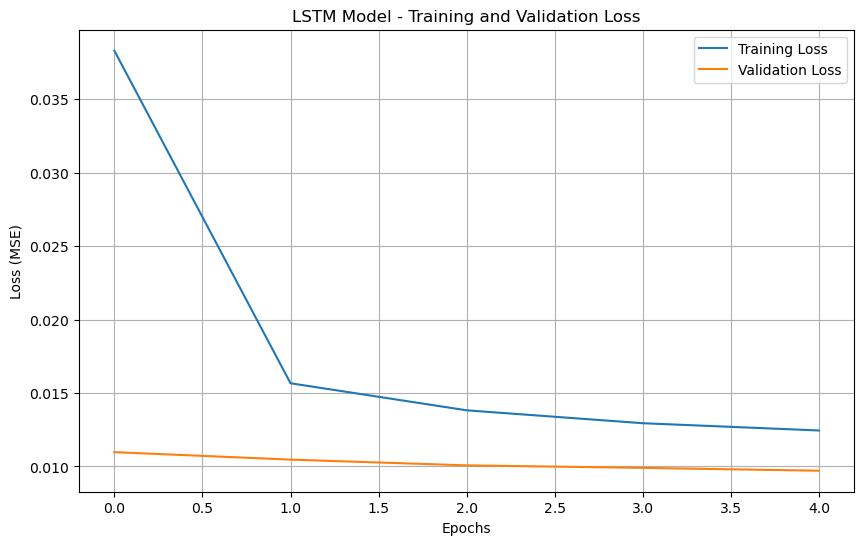

In [36]:
# LSTM — Multi-step forecasting
# Criar o modelo LSTM com os melhores parâmetros
lstm_model = create_lstm_model_24(
    input_shape=X_train.shape[1:], 
    horizon=HORIZON
)

lstm_model.summary()

# Treino do modelo
lstm_model_history = lstm_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[earlystop],
    verbose=1,
    shuffle=False
)

y_pred_lstm = lstm_model.predict(X_test, verbose=0)


# Curvas de loss (treino vs validação)
plt.figure(figsize=(10, 6))
plt.plot(lstm_model_history.history['loss'], label='Training Loss')
plt.plot(lstm_model_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid()
plt.show()


The multi-step evaluation highlights the increased difficulty of forecasting further into the future. As expected, prediction errors increase with the forecast horizon for both models, reflecting the accumulation of uncertainty over time.
At step 1 (t+1h), the GRU slightly outperforms the LSTM, achieving lower MAE (8.96 vs. 9.05), RMSE (10.37 vs. 10.57) and MAPE (20.75% vs. 21.15%). This indicates that the GRU provides more accurate short-term predictions even when trained in a multi-step setting.
At step 12 (t+12h), both models exhibit very similar performance. Error values increase substantially (MAPE ≈ 26% for both), and the differences between GRU and LSTM become negligible, suggesting that model choice has less impact at intermediate horizons where uncertainty dominates.
At step 24 (t+24h), the GRU again shows a small advantage, with lower MAE (10.47 vs. 10.84), RMSE (12.26 vs. 12.71) and MAPE (26.04% vs. 27.06%). Although the gap is modest, the GRU remains consistently more accurate across all evaluated steps.
The prediction plot supports these numerical findings. Both models capture the general level of the series but struggle to reproduce sharp peaks and sudden drops, leading to smoother forecasts. This smoothing effect becomes more pronounced at longer horizons, explaining the higher error values observed at t+12h and t+24h.
Final conclusion
Overall, both models perform comparably in the multi-step setting, but the GRU consistently delivers slightly better accuracy across all horizons. While multi-step forecasting remains challenging, the results indicate that the GRU is the more robust choice for 24-hour-ahead forecasting, offering marginally better performance and more stable predictions as the forecast horizon increases


 Avaliação Multi-Step (H=24) 

 Passo 1 (t+1h) 
GRU : MAE=8.9615, RMSE=10.3692, MAPE=20.75%
LSTM: MAE=9.0502, RMSE=10.5658, MAPE=21.15%

 Passo 12 (t+12h) 
GRU : MAE=10.9066, RMSE=12.7668, MAPE=26.05%
LSTM: MAE=10.8940, RMSE=12.7137, MAPE=25.94%

 Passo 24 (t+24h) 
GRU : MAE=10.4694, RMSE=12.2559, MAPE=26.04%
LSTM: MAE=10.8438, RMSE=12.7137, MAPE=27.06%


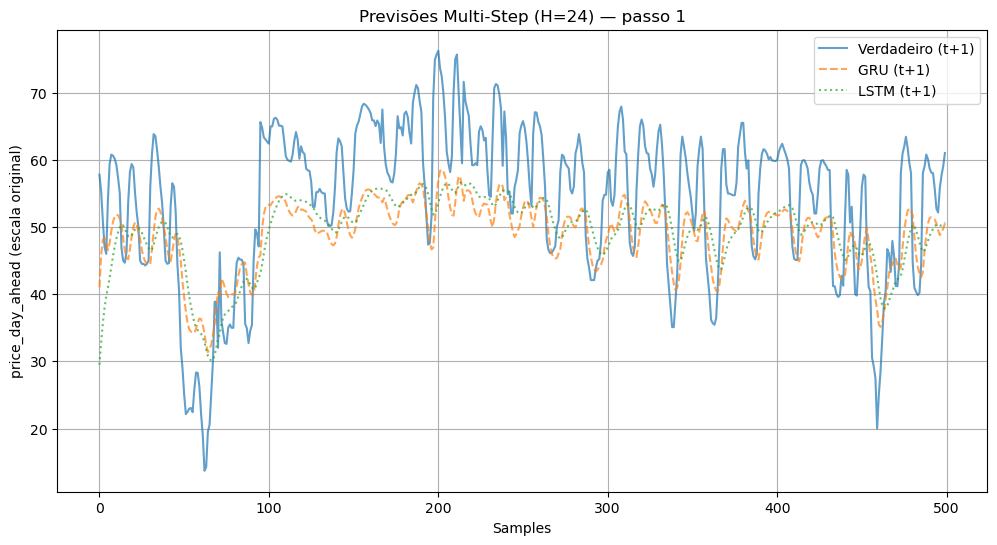

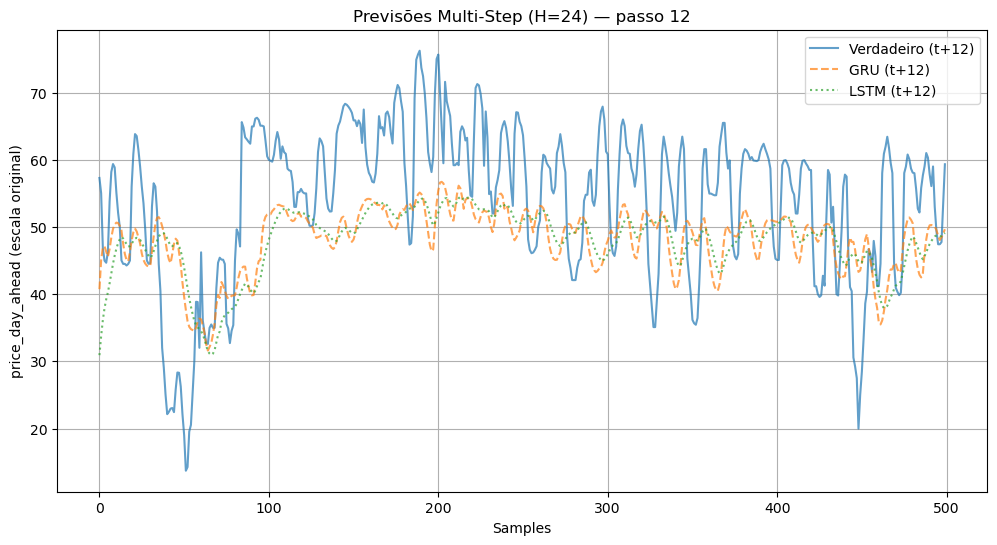

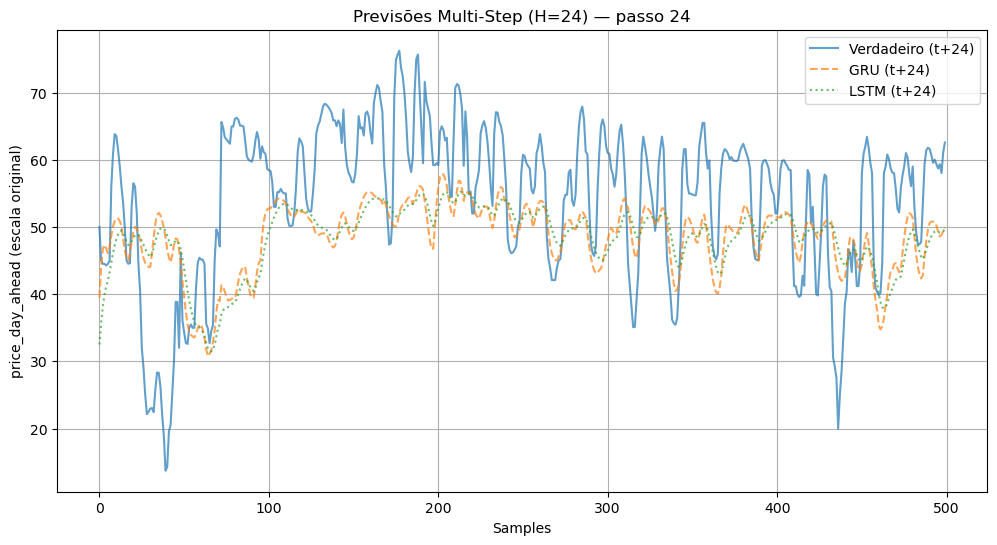

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuração
HORIZON = 24
steps_to_eval = [0, 11, 23]   # 1h, 12h, 24h

# Dados corretos (H=24)
y_test_multi = results_prepared[HORIZON]["y_test"]
scaler_y = results_prepared[HORIZON]["scaler_y"]

# garantir shapes (N,24)
if y_pred_gru.ndim == 1:
    y_pred_gru = y_pred_gru.reshape(-1, HORIZON)

if y_pred_lstm.ndim == 1:
    y_pred_lstm = y_pred_lstm.reshape(-1, HORIZON)

if y_test_multi.ndim == 1:
    y_test_multi = y_test_multi.reshape(-1, HORIZON)

# alinhar nº de amostras (seguro)
n_min = min(y_test_multi.shape[0], y_pred_gru.shape[0], y_pred_lstm.shape[0])
y_test_multi = y_test_multi[:n_min, :]
y_pred_gru   = y_pred_gru[:n_min, :]
y_pred_lstm  = y_pred_lstm[:n_min, :]

# inverse transform (multi-step: flatten -> inverse -> reshape) para ficar tudo em escala original
y_test_multi = scaler_y.inverse_transform(
    y_test_multi.reshape(-1, 1)
).reshape(y_test_multi.shape)

y_pred_gru = scaler_y.inverse_transform(
    y_pred_gru.reshape(-1, 1)
).reshape(y_pred_gru.shape)

y_pred_lstm = scaler_y.inverse_transform(
    y_pred_lstm.reshape(-1, 1)
).reshape(y_pred_lstm.shape)

# Avaliação por passo
def evaluate_step(y_true, y_pred, step):
    mae  = mean_absolute_error(y_true[:, step], y_pred[:, step])
    rmse = np.sqrt(mean_squared_error(y_true[:, step], y_pred[:, step]))
    denom = np.maximum(np.abs(y_true[:, step]), 1e-8)
    mape = np.mean(np.abs((y_true[:, step] - y_pred[:, step]) / denom)) * 100
    return mae, rmse, mape

print("\n Avaliação Multi-Step (H=24) ")

for step in steps_to_eval:
    gru_mae, gru_rmse, gru_mape = evaluate_step(y_test_multi, y_pred_gru, step)
    lstm_mae, lstm_rmse, lstm_mape = evaluate_step(y_test_multi, y_pred_lstm, step)

    print(f"\n Passo {step+1} (t+{step+1}h) ")
    print(f"GRU : MAE={gru_mae:.4f}, RMSE={gru_rmse:.4f}, MAPE={gru_mape:.2f}%")
    print(f"LSTM: MAE={lstm_mae:.4f}, RMSE={lstm_rmse:.4f}, MAPE={lstm_mape:.2f}%")

# Plots (3 passos)
num_samples = 500
n = min(num_samples, y_test_multi.shape[0])

for step in steps_to_eval:
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_multi[:n, step], label=f"Verdadeiro (t+{step+1})", alpha=0.7)
    plt.plot(y_pred_gru[:n, step], label=f"GRU (t+{step+1})", linestyle="--", alpha=0.7)
    plt.plot(y_pred_lstm[:n, step], label=f"LSTM (t+{step+1})", linestyle=":", alpha=0.7)
    plt.legend()
    plt.title(f"Previsões Multi-Step (H=24) — passo {step+1}")
    plt.xlabel("Samples")
    plt.ylabel("price_day_ahead (escala original)")
    plt.grid()
    plt.show()


## Model Evaluation

1-hour ahead metrics:


,MAE,RMSE,MAPE
RandomForest,1.437308,1.437308,30.322961
GradientBoosting,0.858017,0.858017,18.101620
XGBoost,1.768994,1.768994,37.320541
LGBM,0.082012,0.082012,1.730207
SARIMA,3.931301,3.931301,82.938837
SARIMAX,1.510306,1.510306,31.862993
SeasonalNaive,15.090000,15.090000,318.354430


24-hour ahead metrics:


,MAE,RMSE,MAPE
RandomForest,9.332458,12.049840,275.631903
GradientBoosting,10.773263,13.429496,301.883807
XGBoost,11.678409,13.808704,332.563363
LGBM,10.247624,13.292274,292.825442
SARIMA,7.293854,13.039759,138.695865
SARIMAX,13.898598,15.045579,374.761152
SeasonalNaive,27.764583,29.487856,706.814911


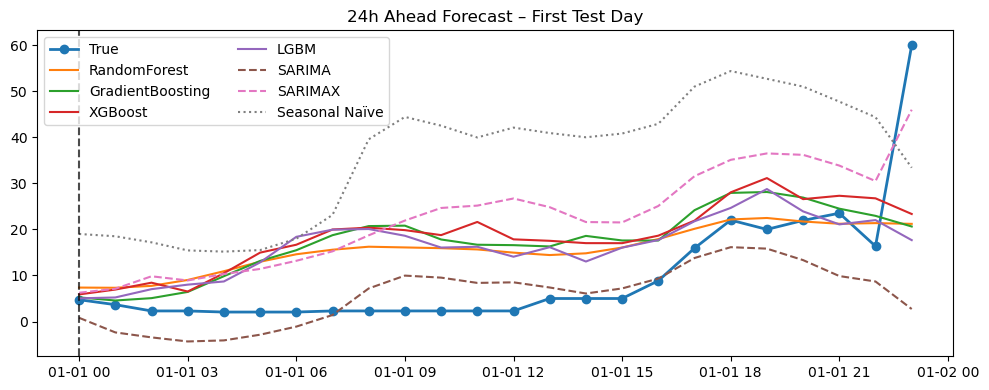

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1-hour ahead ---
metrics_1h = {}

# Add ML model predictions
for name, pred in pred_1h.items():
    metrics_1h[name] = {
        'MAE': mean_absolute_error([true_1h], [pred]),
        'RMSE': np.sqrt(mean_squared_error([true_1h], [pred])),
        'MAPE': np.mean(np.abs((true_1h - pred) / true_1h)) * 100
    }

# Add SARIMA
metrics_1h['SARIMA'] = {
    'MAE': mean_absolute_error([true_1h], [sarima_forecast_1h.values[0]]),
    'RMSE': np.sqrt(mean_squared_error([true_1h], [sarima_forecast_1h.values[0]])),
    'MAPE': np.mean(np.abs((true_1h - sarima_forecast_1h.values[0]) / true_1h)) * 100
}

# Add SARIMAX
metrics_1h['SARIMAX'] = {
    'MAE': mean_absolute_error([true_1h], [sarimax_forecast_1h.values[0]]),
    'RMSE': np.sqrt(mean_squared_error([true_1h], [sarimax_forecast_1h.values[0]])),
    'MAPE': np.mean(np.abs((true_1h - sarimax_forecast_1h.values[0]) / true_1h)) * 100
}

# --- 1-hour ahead Seasonal Naïve ---
seasonal_naive_1h = y_train.iloc[-seasonal_lag]
metrics_1h['SeasonalNaive'] = {
    'MAE': mean_absolute_error([true_1h], [seasonal_naive_1h]),
    'RMSE': np.sqrt(mean_squared_error([true_1h], [seasonal_naive_1h])),
    'MAPE': np.mean(np.abs((true_1h - seasonal_naive_1h) / true_1h)) * 100
}

df_metrics_1h = pd.DataFrame(metrics_1h).T  # transpose for readability

# --- 24-hour ahead ---
metrics_24h = {}

# ML models
for name, pred in pred_24h.items():
    metrics_24h[name] = {
        'MAE': mean_absolute_error(true_24h, pred),
        'RMSE': np.sqrt(mean_squared_error(true_24h, pred)),
        'MAPE': np.mean(np.abs((true_24h - pred) / true_24h)) * 100
    }

# SARIMA
metrics_24h['SARIMA'] = {
    'MAE': mean_absolute_error(true_24h, sarima_forecast_24h.values),
    'RMSE': np.sqrt(mean_squared_error(true_24h, sarima_forecast_24h.values)),
    'MAPE': np.mean(np.abs((true_24h - sarima_forecast_24h.values) / true_24h)) * 100
}

# SARIMAX
metrics_24h['SARIMAX'] = {
    'MAE': mean_absolute_error(true_24h, sarimax_forecast_24h.values),
    'RMSE': np.sqrt(mean_squared_error(true_24h, sarimax_forecast_24h.values)),
    'MAPE': np.mean(np.abs((true_24h - sarimax_forecast_24h.values) / true_24h)) * 100
}

df_metrics_24h = pd.DataFrame(metrics_24h).T


seasonal_lag = 24
# --- 24-hour ahead Seasonal Naïve ---
seasonal_naive_24h = y_train.iloc[-seasonal_lag*2:-seasonal_lag].values
metrics_24h['SeasonalNaive'] = {
    'MAE': mean_absolute_error(true_24h, seasonal_naive_24h),
    'RMSE': np.sqrt(mean_squared_error(true_24h, seasonal_naive_24h)),
    'MAPE': np.mean(np.abs((true_24h - seasonal_naive_24h) / true_24h)) * 100
}

df_metrics_24h = pd.DataFrame(metrics_24h).T

df_metrics_1h.to_csv("metrics_1h.csv")
df_metrics_24h.to_csv("metrics_24h.csv")

# df_metrics_1h = pd.read_csv("metrics_1h.csv")
# df_metrics_24h = pd.read_csv("metrics_24h.csv")

# --- Display ---
print("1-hour ahead metrics:")
display(df_metrics_1h)

print("24-hour ahead metrics:")
display(df_metrics_24h)

plt.figure(figsize=(10,4))

# True values
plt.plot(y_test.index[:24], true_24h, label="True", marker='o', linewidth=2)

# ML models
for name, pred in pred_24h.items():
    plt.plot(y_test.index[:24], pred, label=name)

# SARIMA
plt.plot(y_test.index[:24],sarima_forecast_24h.values,label="SARIMA",linestyle='--')

# SARIMAX
plt.plot(y_test.index[:24],sarimax_forecast_24h.values,label="SARIMAX",linestyle='--')

# Seasonal Naïve (24h)
plt.plot(y_test.index[:24],seasonal_naive_24h,label="Seasonal Naïve",linestyle=':')

# Forecast origin
plt.axvline(y_test.index[0], color='k', linestyle='--', alpha=0.7)

plt.title("24h Ahead Forecast – First Test Day")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


#### Full test period prediction

In order to predict the full test period, we selected the best ML model (LGBM) and the best statistical model (SARIMA).

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 149, number of used features: 8
[LightGBM] [Info] Start training from score 47.411922
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

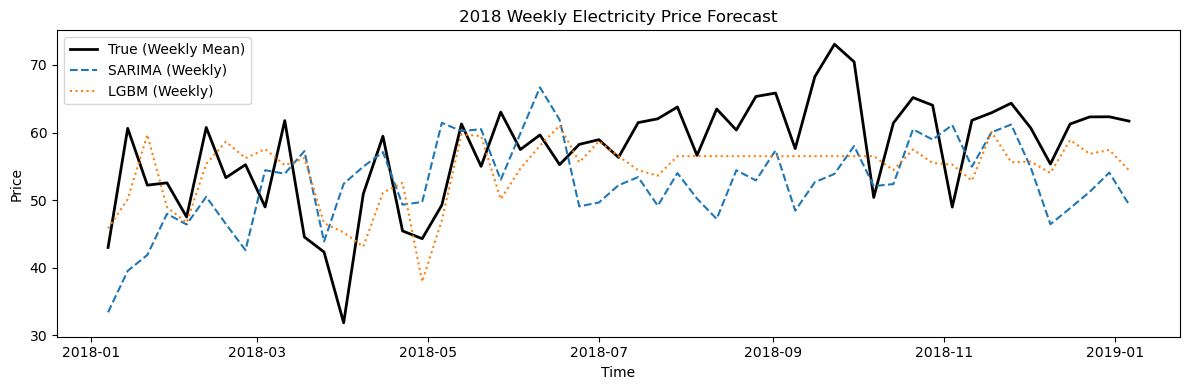

Weekly forecast metrics (2018):


,MAE,RMSE,MAPE
SARIMA,8.466039,9.702335,15.075305
LGBM,6.094688,7.179911,10.797089


In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

y_weekly = df['price_day_ahead'].resample('W').mean()

y_weekly_train = y_weekly.loc[:'2017-12-31']
y_weekly_test  = y_weekly.loc['2018-01-01':]


sarima_weekly = SARIMAX(
    y_weekly_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_weekly_forecast = sarima_weekly.get_forecast(
    steps=len(y_weekly_test)
).predicted_mean

sarima_weekly_forecast.index = y_weekly_test.index

def make_lagged_df(series, n_lags):
    df_lagged = pd.DataFrame({'y': series})
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = series.shift(i)
    return df_lagged.dropna()

n_lags = 8  # 8 weeks history

weekly_lagged = make_lagged_df(y_weekly, n_lags)

train_weekly = weekly_lagged.loc[:'2017-12-31']
test_weekly  = weekly_lagged.loc['2018-01-01':]

X_train = train_weekly.drop(columns='y')
y_train = train_weekly['y']

X_test = test_weekly.drop(columns='y')
y_test = test_weekly['y']

lgbm_weekly = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=50,
    subsample=0.6,
    random_state=42,
    n_jobs=-1
)

lgbm_weekly.fit(X_train, y_train)

lgbm_weekly_forecast = pd.Series(
    lgbm_weekly.predict(X_test),
    index=y_test.index
)

plt.figure(figsize=(12, 4))

plt.plot(
    y_weekly_test.index,
    y_weekly_test,
    label="True (Weekly Mean)",
    color="black",
    linewidth=2
)

plt.plot(
    sarima_weekly_forecast.index,
    sarima_weekly_forecast,
    label="SARIMA (Weekly)",
    linestyle="--"
)

plt.plot(
    lgbm_weekly_forecast.index,
    lgbm_weekly_forecast,
    label="LGBM (Weekly)",
    linestyle=":"
)

plt.title("2018 Weekly Electricity Price Forecast")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

metrics_weekly = pd.DataFrame({
    'SARIMA': {
        'MAE': mean_absolute_error(y_weekly_test, sarima_weekly_forecast),
        'RMSE': np.sqrt(mean_squared_error(y_weekly_test, sarima_weekly_forecast)),
        'MAPE': np.mean(
            np.abs((y_weekly_test - sarima_weekly_forecast) / y_weekly_test)
        ) * 100
    },
    'LGBM': {
        'MAE': mean_absolute_error(y_weekly_test, lgbm_weekly_forecast),
        'RMSE': np.sqrt(mean_squared_error(y_weekly_test, lgbm_weekly_forecast)),
        'MAPE': np.mean(
            np.abs((y_weekly_test - lgbm_weekly_forecast) / y_weekly_test)
        ) * 100
    }
}).T

print("Weekly forecast metrics (2018):")
metrics_weekly


#### Conclusion

Considering accuracy, stability, efficiency, interpretability, and forecast behavior, SARIMA is the best-performing and most suitable model for electricity price forecasting in this study. 

Over the test period, SARIMA produces smoother and more realistic forecasts, avoiding the exaggerated volatility and extreme errors seen in ML models (reflected by very high MAPE). Seasonal Naïve confirms that SARIMA adds substantial value beyond baseline seasonality, while SARIMAX shows no benefit from exogenous variables. 

SARIMA is significantly lighter than ensemble ML models (Random Forest, XGBoost, LGBM), requiring less training time, fewer hyperparameters, and no feature scaling or multi-output wrappers. This makes it computationally efficient and easier to maintain.

In terms of prediction over the full test period, SARIMA seems to keep the seasonality accross the test period. Although, LGBM has the better metrics values for MAE, RMSE and MAPE.  
